# **Barbados Public EV Charger Analysis:** _**Access, Demand, Utilisation and Equity**_

Author: Rasheena Dow
<br>Date: 2025\-2026</br>

## Environmental Research Questions:

- How are public EV chargers used in terms of session frequency, duration, and energy delivered?
- Which charger types or locations experience the highest demand?
- When do peak charging periods occur during the day and week?
- Where are chargers underutilized or frequently operating at capacity?
- How does charger usage vary across parishes?

Link to GitHub repository: \[[https://github.com/rasheenadow/Barbados\-Public\-EV\-Charger\-Analysis](https://github.com/rasheenadow/Barbados-Public-EV-Charger-Analysis) \]  



In [31]:
# Load libraries
library(sf)
library(ggplot2)
library(ggspatial)
library(geodata)
library(dplyr)
library(ggrepel)
library(tidyverse)
library(scales)
library(ggthemes)
library(lubridate)
library(patchwork)

# Confirm current directory 
getwd()

# Confirm folder structure 
list.files("/home/user/capstone", recursive = TRUE)

# verify folder exists
list.files("/home/user/capstone")

# Set working directory
setwd("/home/user/capstone/02_processed_data")

# Confirm it worked
getwd()

# Load datasets 
sessions <- read_csv("Barbados_public_EV_charger_sessions_full_2025_cleaned.csv")
stats <- read_csv("Barbados_public_EV_charger_statistics_2025_cleaned.csv")
population <- read_csv("Barbados_2020_Population_by_Parish_cleaned.csv")

# Preview data
head(sessions)
head(stats)
head(population)

[1] "/home/user/capstone/02_processed_data"

[1] "01_raw_data/Barbados_2020_Population_by_Parish.csv"                                         
 [2] "01_raw_data/Barbados_public_EV_charger_sessions_full_2025.csv"                              
 [3] "01_raw_data/Barbados_public_EV_charger_statistics_2025.csv"                                 
 [4] "02_processed_data/Barbados_2020_Population_by_Parish_cleaned.csv"                           
 [5] "02_processed_data/Barbados_public_EV_charger_sessions_full_2025_cleaned.csv"                
 [6] "02_processed_data/Barbados_public_EV_charger_statistics_2025_cleaned.csv"                   
 [7] "03_scripts/Barbados-Public-EV-Charger-Analysis.ipynb"                                       
 [8] "03_scripts/githubnotebook.ipynb"                                                            
 [9] "05_outputs/figure1.png"                                                                     
[10] "05_outputs/figure2.png"                                                                     
[11] "05_outputs/figure3.png"                                                                     
[12] "05_outputs/figure4.png"                                                                     
[13] "05_outputs/figure5.png"                                                                     
[14] "05_outputs/figure6.png"                                                                     
[15] "06_docs/Excel Preprocessing Sessions and Statistics File Changes (from Raw to Cleaned).xlsx"
[16] "rosm.cache/cartolight/11_684_947.png"                                                       
[17] "rosm.cache/cartolight/11_684_948.png"                                                       
[18] "rosm.cache/cartolight/11_684_949.png"                                                       
[19] "rosm.cache/cartolight/11_685_947.png"                                                       
[20] "rosm.cache/cartolight/11_685_948.png"                                                       
[21] "rosm.cache/cartolight/11_685_949.png"                                                       
[22] "rosm.cache/cartolight/11_686_947.png"                                                       
[23] "rosm.cache/cartolight/11_686_948.png"                                                       
[24] "rosm.cache/cartolight/11_686_949.png"                                                       
[25] "rosm.cache/osm/11_684_947.png"                                                              
[26] "rosm.cache/osm/11_684_948.png"                                                              
[27] "rosm.cache/osm/11_684_949.png"                                                              
[28] "rosm.cache/osm/11_685_947.png"                                                              
[29] "rosm.cache/osm/11_685_948.png"                                                              
[30] "rosm.cache/osm/11_685_949.png"                                                              
[31] "rosm.cache/osm/12_1369_1895.png"                                                            
[32] "rosm.cache/osm/12_1369_1896.png"                                                            
[33] "rosm.cache/osm/12_1369_1897.png"                                                            
[34] "rosm.cache/osm/12_1369_1898.png"                                                            
[35] "rosm.cache/osm/12_1370_1895.png"                                                            
[36] "rosm.cache/osm/12_1370_1896.png"                                                            
[37] "rosm.cache/osm/12_1370_1897.png"                                                            
[38] "rosm.cache/osm/12_1370_1898.png"                                                            
[39] "rosm.cache/osm/12_1371_1895.png"                                                            
[40] "rosm.cache/osm/12_1371_1896.png"                                                            
[41] "rosm.cache/osm/12_1371_1897.png"   

[1] "01_raw_data"          "02_processed_data"    "03_scripts"          
[4] "04_metadata"          "05_outputs"           "06_docs"             
[7] "rosm.cache"           "Visualisations.ipynb"

[1] "/home/user/capstone/02_processed_data"

Rows: 11764 Columns: 16


...

── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): parish
dbl (3): population, area_sq_km, area_sq_miles



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


session_start_utc,session_end_utc,session_start_local,session_end_local,local_time_zone,session_duration_min,idle_duration_min,energy_provided_kWh,session_peak_power_kW,session_avg_power_kW,charger_display_id,connector_type,charger_max_power_kW,location_name,location_parish,authentication_type
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
12/31/2024 23:26,1/1/2025 0:25,12/31/2024 19:26,12/31/2024 20:25,America/Barbados,59.02,2.48,24.9,33.8,25.4,MP-025,CCS_2,25,Massy Warrens,St. Michael,SYSTEM
1/1/2025 12:53,1/1/2025 13:27,1/1/2025 8:53,1/1/2025 9:27,America/Barbados,33.74,0.80,5.9,28.1,25.0,MP-025,CCS_2,25,Massy Warrens,St. Michael,SYSTEM
1/2/2025 10:17,1/2/2025 10:52,1/2/2025 6:17,1/2/2025 6:52,America/Barbados,34.38,0.80,14.5,28.1,25.3,MP-025,CCS_2,25,Massy Warrens,St. Michael,SYSTEM
1/2/2025 12:58,1/2/2025 13:06,1/2/2025 8:58,1/2/2025 9:06,America/Barbados,7.95,1.03,2.8,24.0,21.4,MP-025,CHADEMO,25,Massy Warrens,St. Michael,SYSTEM
1/2/2025 13:53,1/2/2025 15:12,1/2/2025 9:53,1/2/2025 11:12,America/Barbados,79.07,1.60,34.8,33.8,26.4,MP-025,CCS_2,25,Massy Warrens,St. Michael,SYSTEM
1/2/2025 17:45,1/2/2025 18:41,1/2/2025 13:45,1/2/2025 14:41,America/Barbados,55.50,0.30,24.7,33.8,27.5,MP-025,CCS_2,25,Massy Warrens,St. Michael,RFID


charger_display_id,location_name,location_parish,local_time_zone,geolocation,start_date,end_date,sessions_count,unique_drivers_count,charging_time_min,energy_provided_kWh
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MP-025,Massy Warrens,St. Michael,America/Barbados,"13.1418840472076,-59.6087500021415",1/1/2025,1/31/2025,167,42,7886.50,3618.0
MP-001,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",1/1/2025,1/31/2025,5,3,89.19,11.0
MP-0079,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",1/1/2025,1/31/2025,15,11,300.82,110.3
MP-001,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",2/1/2025,2/28/2025,7,3,505.95,62.4
MP-025,Massy Warrens,St. Michael,America/Barbados,"13.1418840472076,-59.6087500021415",2/1/2025,2/28/2025,133,39,6038.50,2728.2
MP-0079,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",2/1/2025,2/28/2025,8,6,140.73,51.6


parish,population,area_sq_km,area_sq_miles
<chr>,<dbl>,<dbl>,<dbl>
St. Lucy,10799,35.2,13.6
St. Andrew,5783,32.1,12.4
St. Joseph,7410,26.6,10.3
St. John,10864,34.7,13.4
St. Philip,30210,60.5,23.4
St. George,23065,44.8,17.3


## Cleaning Data

Relevant Lectures:
<br>**Course 3, Module 10**: "Data Cleaning Pt. 1" and "Data Cleaning Pt. 2" by JRS — Introduces key principles and practical data-cleaning techniques in R.</br>
<br>**Course 3, Module 8**: "Using EDA to Clean Data" by Angel — Discusses identifying common issues in data and addressing them.</br>



In [28]:
# Clean sessions dataset
sessions_clean <- sessions %>%
  mutate(
    # Convert datetime fields
    session_start_utc = mdy_hm(session_start_utc),
    session_end_utc   = mdy_hm(session_end_utc),
    session_start_local = mdy_hm(session_start_local),
    session_end_local   = mdy_hm(session_end_local),

    # Standardize parish names (important for joins)
    location_parish = str_trim(location_parish),

    # Ensure numeric consistency
    session_duration_min = as.numeric(session_duration_min),
    energy_provided_kWh = as.numeric(energy_provided_kWh)
  ) %>%
  filter(
    !is.na(session_duration_min),
    session_duration_min > 0,
    energy_provided_kWh >= 0
  )

print(sessions_clean)


# Clean stats dataset
stats_clean <- stats %>%
  mutate(
    start_date = mdy(start_date),
    end_date = mdy(end_date),
    location_parish = str_trim(location_parish)
  ) %>%
  distinct()

print(stats_clean)

# Clean populations dataset
population_clean <- population %>%
  mutate(
    parish = str_trim(parish)
  )
print(population_clean)

# A tibble: 11,559 × 16
   session_start_utc   session_end_utc     session_start_local
   <dttm>              <dttm>              <dttm>             
 1 2024-12-31 23:26:00 2025-01-01 00:25:00 2024-12-31 19:26:00
 2 2025-01-01 12:53:00 2025-01-01 13:27:00 2025-01-01 08:53:00
 3 2025-01-02 10:17:00 2025-01-02 10:52:00 2025-01-02 06:17:00
 4 2025-01-02 12:58:00 2025-01-02 13:06:00 2025-01-02 08:58:00
 5 2025-01-02 13:53:00 2025-01-02 15:12:00 2025-01-02 09:53:00
 6 2025-01-02 17:45:00 2025-01-02 18:41:00 2025-01-02 13:45:00
 7 2025-01-02 19:37:00 2025-01-02 20:12:00 2025-01-02 15:37:00
 8 2025-01-02 20:39:00 2025-01-02 21:51:00 2025-01-02 16:39:00
 9 2025-01-03 11:20:00 2025-01-03 12:33:00 2025-01-03 07:20:00
10 2025-01-03 14:11:00 2025-01-03 15:06:00 2025-01-03 10:11:00
# ℹ 11,549 more rows
# ℹ 13 more variables: session_end_local <dttm>, local_time_zone <chr>,
#   session_duration_min <dbl>, idle_duration_min <dbl>,
#   energy_provided_kWh <dbl>, session_peak_power_kW <dbl>,
#   sessio

# A tibble: 470 × 11
   charger_display_id location_name  location_parish local_time_zone geolocation
   <chr>              <chr>          <chr>           <chr>           <chr>      
 1 MP-025             Massy Warrens  St. Michael     America/Barbad… 13.1418840…
 2 MP-001             Massy Sunset … St. James       America/Barbad… 13.1850239…
 3 MP-0079            Massy Sunset … St. James       America/Barbad… 13.1850239…
 4 MP-001             Massy Sunset … St. James       America/Barbad… 13.1850239…
 5 MP-025             Massy Warrens  St. Michael     America/Barbad… 13.1418840…
 6 MP-0079            Massy Sunset … St. James       America/Barbad… 13.1850239…
 7 MP-025             Massy Warrens  St. Michael     America/Barbad… 13.1418840…
 8 MP-001             Massy Sunset … St. James       America/Barbad… 13.1850239…
 9 MP-0079            Massy Sunset … St. James       America/Barbad… 13.1850239…
10 MP-025             Massy Warrens  St. Michael     America/Barbad… 13.1418840…
# ℹ 460

# A tibble: 11 × 4
   parish        population area_sq_km area_sq_miles
   <chr>              <dbl>      <dbl>         <dbl>
 1 St. Lucy           10799       35.2          13.6
 2 St. Andrew          5783       32.1          12.4
 3 St. Joseph          7410       26.6          10.3
 4 St. John           10864       34.7          13.4
 5 St. Philip         30210       60.5          23.4
 6 St. George         23065       44.8          17.3
 7 Christ Church      53801       60.8          23.5
 8 St. Peter          13088       31.5          12.2
 9 St. Thomas         15173       33.8          13.1
10 St. Michael        86465       37.7          14.6
11 St. James          26698       34.5          13.3


## Exploratory Data Analysis (EDA)

Relevant Lectures:
<br>**Course 3, Module 9**: "Conducting Exploratory Data Analysis (EDA)" by JRS — Introduces how to explore relationships between variables and visualise data.</br>
<br>**Course 3, Module 10**: "Creating Data Visualizations for EDA" by JRS — Focuses on visualizing relationships between variables using linear regression and other plots.</br>



[1] "/home/user/capstone"

[1] "Barbados_2020_Population_by_Parish.csv"                         
 [2] "Barbados_public_EV_charger_sessions_full_2025_cleaned.csv"      
 [3] "Barbados_public_EV_charger_sessions_full_2025.csv"              
 [4] "Barbados_public_EV_charger_statistics_2025_cleaned.csv"         
 [5] "Barbados_public_EV_charger_statistics_2025.csv"                 
 [6] "Barbados-Public-EV-Charger-Analysis.html"                       
 [7] "Barbados-Public-EV-Charger-Analysis.ipynb"                      
 [8] "Barbados-Public-EV-Charger-Analysis.pdf"                        
 [9] "Capstone_Project_Barbados_Public_EV_Charger_Analysis.ipynb"     
[10] "data"                                                           
[11] "data_cleaning.ipynb"                                            
[12] "equity_share_plot.png"                                          
[13] "figure.png"                                                     
[14] "figure1_per_capita.png"                                         
[15] "figure1.png"                                                    
[16] "figure2.png"                                                    
[17] "figure3.png"                                                    
[18] "figure4_map.png"                                                
[19] "figure4.png"                                                    
[20] "figure5.png"                                                    
[21] "figure6.png"                                                    
[22] "githubnotebook.ipynb"                                           
[23] "rosm.cache"                                                     
[24] "script"                                                         
[25] "Sessions and Statistics File Changes (from Raw to Cleaned).xlsx"
[26] "Visualisations.ipynb"

[1] "Barbados_2020_Population_by_Parish.csv"                         
[2] "Barbados_public_EV_charger_sessions_full_2025_cleaned.csv"      
[3] "Barbados_public_EV_charger_sessions_full_2025.csv"              
[4] "Barbados_public_EV_charger_statistics_2025_cleaned.csv"         
[5] "Barbados_public_EV_charger_statistics_2025.csv"                 
[6] "Sessions and Statistics File Changes (from Raw to Cleaned).xlsx"

Rows: 11764 Columns: 16


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): session_start_utc, session_end_utc, session_start_local, session_e...
dbl  (6): session_duration_min, idle_duration_min, energy_provided_kWh, sess...


...

Statistics: 470 rows x 11 cols


Population: 11 rows x 4 cols


session_start_utc,session_end_utc,session_start_local,session_end_local,local_time_zone,session_duration_min,idle_duration_min,energy_provided_kWh,session_peak_power_kW,session_avg_power_kW,charger_display_id,connector_type,charger_max_power_kW,location_name,location_parish,authentication_type
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
12/31/2024 23:26,1/1/2025 0:25,12/31/2024 19:26,12/31/2024 20:25,America/Barbados,59.02,2.48,24.9,33.8,25.4,MP-025,CCS_2,25,Massy Warrens,St. Michael,SYSTEM
1/1/2025 12:53,1/1/2025 13:27,1/1/2025 8:53,1/1/2025 9:27,America/Barbados,33.74,0.80,5.9,28.1,25.0,MP-025,CCS_2,25,Massy Warrens,St. Michael,SYSTEM
1/2/2025 10:17,1/2/2025 10:52,1/2/2025 6:17,1/2/2025 6:52,America/Barbados,34.38,0.80,14.5,28.1,25.3,MP-025,CCS_2,25,Massy Warrens,St. Michael,SYSTEM
1/2/2025 12:58,1/2/2025 13:06,1/2/2025 8:58,1/2/2025 9:06,America/Barbados,7.95,1.03,2.8,24.0,21.4,MP-025,CHADEMO,25,Massy Warrens,St. Michael,SYSTEM
1/2/2025 13:53,1/2/2025 15:12,1/2/2025 9:53,1/2/2025 11:12,America/Barbados,79.07,1.60,34.8,33.8,26.4,MP-025,CCS_2,25,Massy Warrens,St. Michael,SYSTEM
1/2/2025 17:45,1/2/2025 18:41,1/2/2025 13:45,1/2/2025 14:41,America/Barbados,55.50,0.30,24.7,33.8,27.5,MP-025,CCS_2,25,Massy Warrens,St. Michael,RFID


charger_display_id,location_name,location_parish,local_time_zone,geolocation,start_date,end_date,sessions_count,unique_drivers_count,charging_time_min,energy_provided_kWh
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MP-025,Massy Warrens,St. Michael,America/Barbados,"13.1418840472076,-59.6087500021415",1/1/2025,1/31/2025,167,42,7886.50,3618.0
MP-001,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",1/1/2025,1/31/2025,5,3,89.19,11.0
MP-0079,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",1/1/2025,1/31/2025,15,11,300.82,110.3
MP-001,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",2/1/2025,2/28/2025,7,3,505.95,62.4
MP-025,Massy Warrens,St. Michael,America/Barbados,"13.1418840472076,-59.6087500021415",2/1/2025,2/28/2025,133,39,6038.50,2728.2
MP-0079,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",2/1/2025,2/28/2025,8,6,140.73,51.6


parish,population,area_sq_km,area_sq_miles
<chr>,<dbl>,<dbl>,<dbl>
St. Lucy,10799,35.2,13.6
St. Andrew,5783,32.1,12.4
St. Joseph,7410,26.6,10.3
St. John,10864,34.7,13.4
St. Philip,30210,60.5,23.4
St. George,23065,44.8,17.3


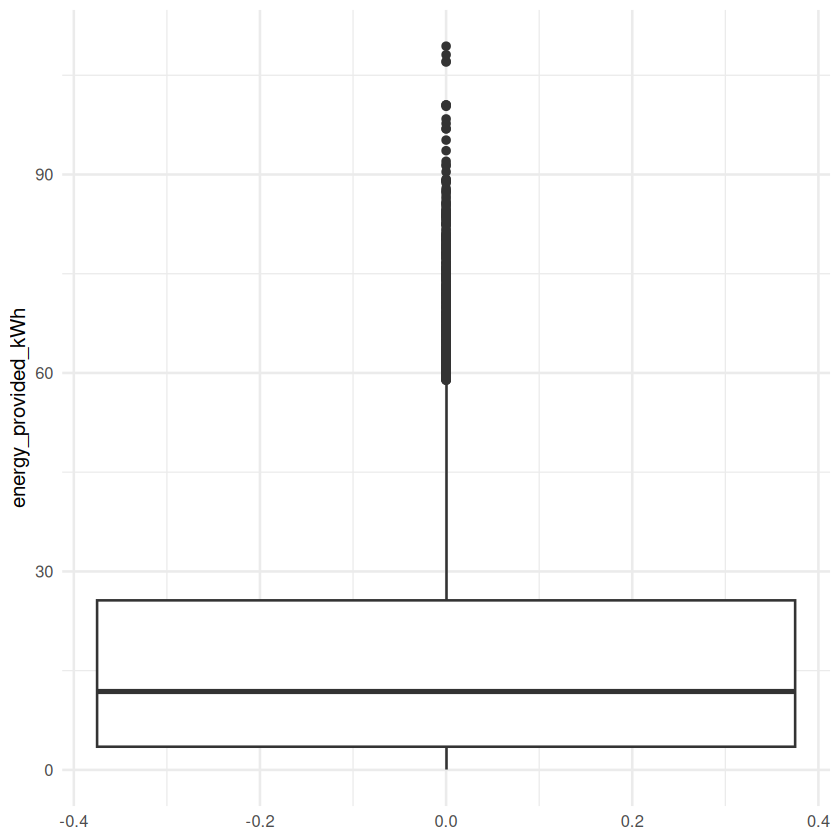

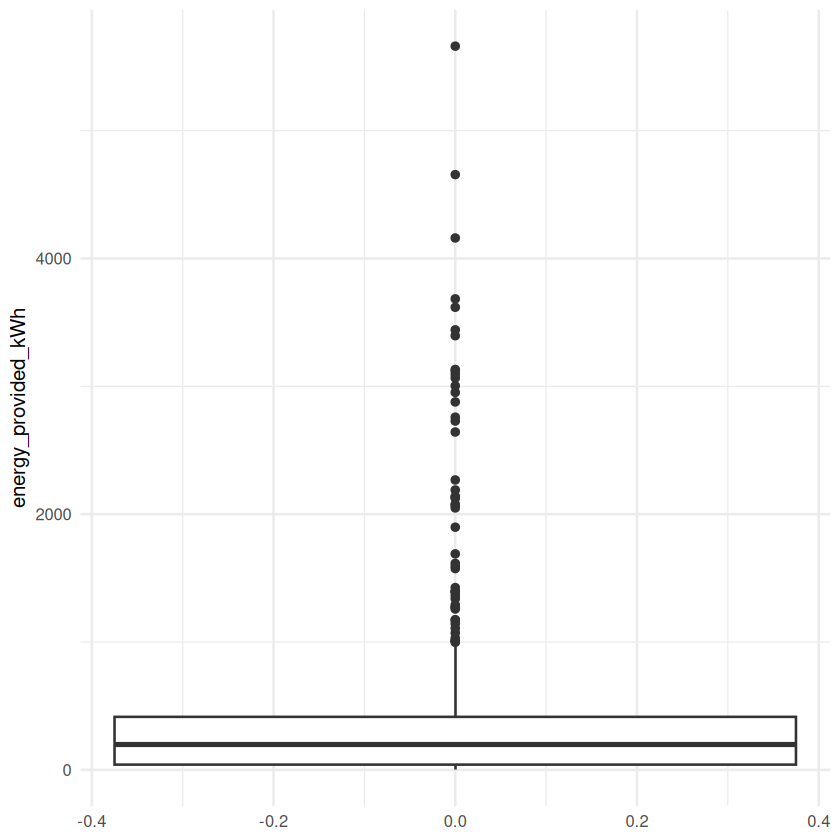

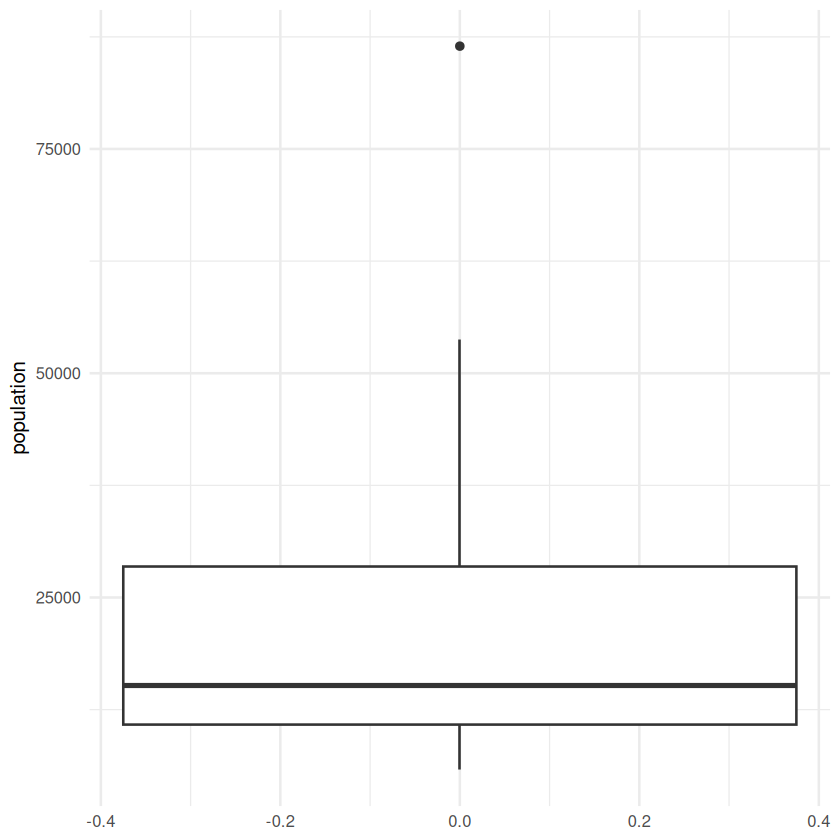

In [101]:
# Exploratory Data Analysis: General and Some Outlier Analysis

# General
# This cell documents the initial exploration of three datasets used in this capstone project

# Confirm your working directory
getwd()

# Check existing files
list.files()
list.files("data")

# Libraries previously loaded
# Set a consistent plot theme
theme_set(theme_minimal(base_size = 12))

# Load data
# Read all three files and confirm dimensions

sessions <- read_csv("data/Barbados_public_EV_charger_sessions_full_2025_cleaned.csv")
stats    <- read_csv("data/Barbados_public_EV_charger_statistics_2025_cleaned.csv")
pop      <- read_csv("data/Barbados_2020_Population_by_Parish.csv")

cat("Sessions:", nrow(sessions), "rows x", ncol(sessions), "cols\n")
cat("Statistics:", nrow(stats), "rows x", ncol(stats), "cols\n")
cat("Population:", nrow(pop), "rows x", ncol(pop), "cols\n")


# Preview each file
head(sessions)
head(stats)
head(pop)

# Outlier Analysis
# Outliers have been flagged here but not dropped for transparency

# Sessions outliers
# - Energy provided
sessions %>%
  ggplot(aes(y = energy_provided_kWh)) +
  geom_boxplot()

# Stats outliers
stats %>%
  ggplot(aes(y = energy_provided_kWh)) +
  geom_boxplot()

# Population outliers
population %>%
  ggplot(aes(y = population)) +
  geom_boxplot()

 session_duration_min idle_duration_min energy_provided_kWh
 Min.   :   0.00      Min.   :   0.00   Min.   :  0.00     
 1st Qu.:  31.63      1st Qu.:   0.00   1st Qu.:  3.50     
 Median :  82.96      Median :   1.07   Median : 11.90     
 Mean   : 176.78      Mean   :  72.44   Mean   : 16.85     
 3rd Qu.: 207.09      3rd Qu.:  37.73   3rd Qu.: 25.62     
 Max.   :8236.73      Max.   :8022.67   Max.   :109.40     
 session_peak_power_kW session_avg_power_kW charger_max_power_kW
 Min.   :    0.00      Min.   :  0.00       Min.   :  7.40      
 1st Qu.:    6.10      1st Qu.:  5.70       1st Qu.:  7.40      
 Median :   12.00      Median :  6.50       Median : 22.00      
 Mean   :   25.69      Mean   : 10.23       Mean   : 17.39      
 3rd Qu.:   24.00      3rd Qu.: 11.60       3rd Qu.: 25.00      
 Max.   :65454.50      Max.   :710.20       Max.   :100.00      

column,n_missing
<chr>,<int>


Duplicate rows in sessions: 0 


Duplicate rows in stats: 0 


Date range: 2024-12-31 12:50:00 to 2025-12-31 23:55:00 


...

Zero-energy sessions: 1314 ( 11.2 %)


Zero-duration sessions: 205 


Sessions > 24 hours: 67 


Peak power outliers > 200 kW: 61 


Wrong timezone (non-Barbados): 0 


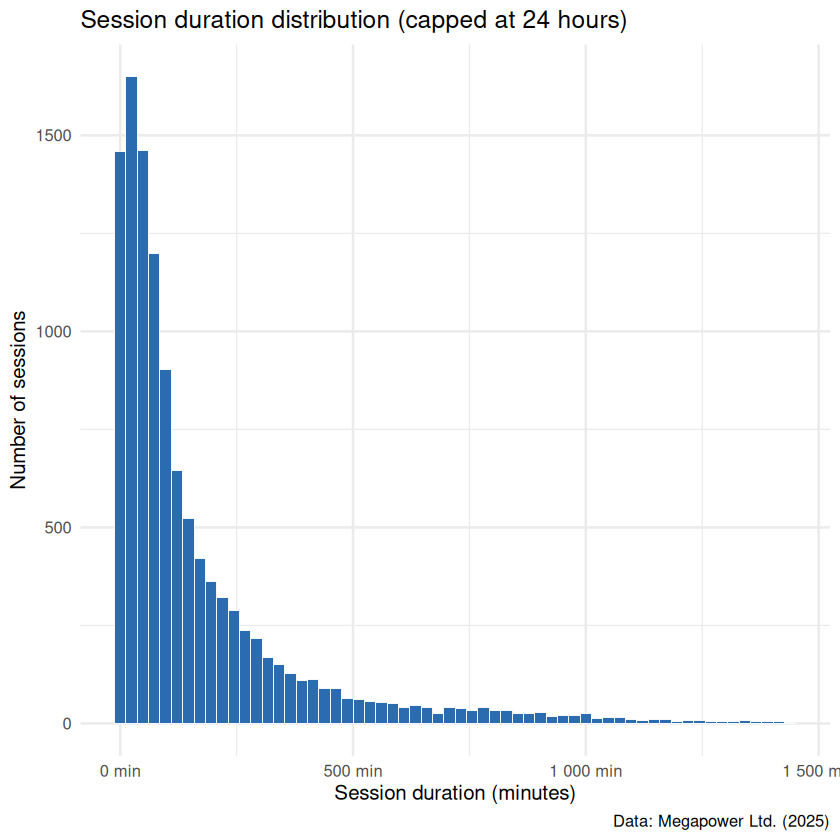

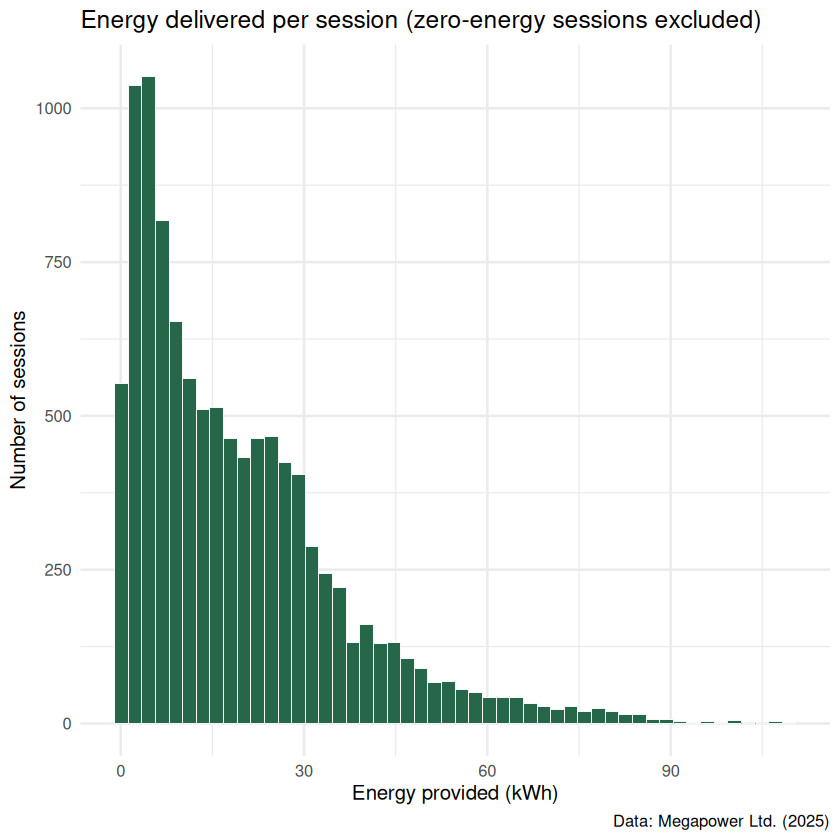

Top 5 chargers: 47.3 % of all sessions


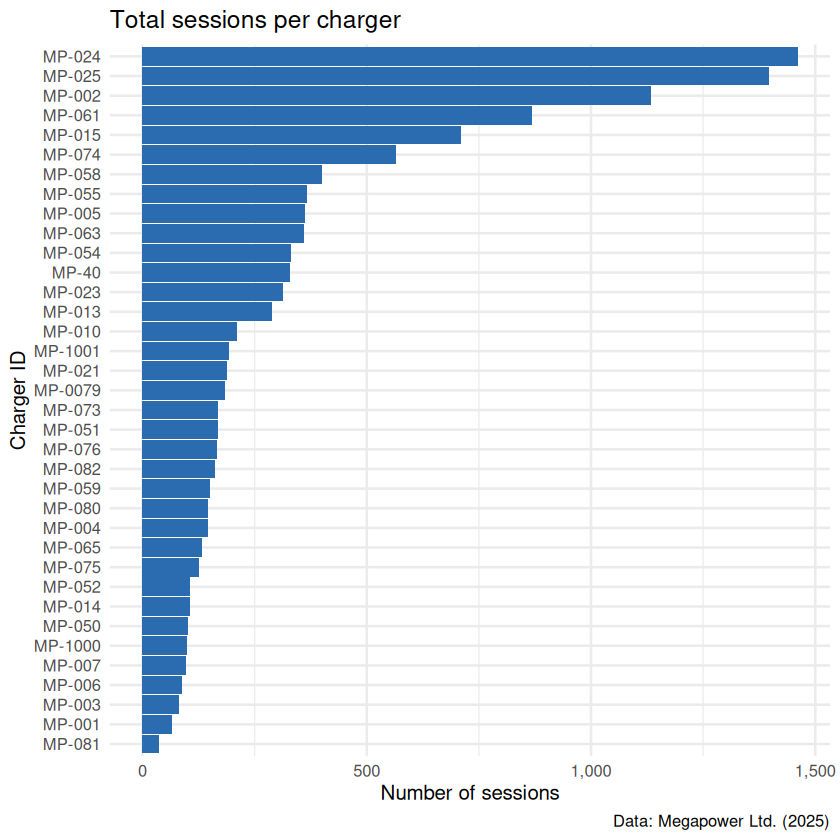

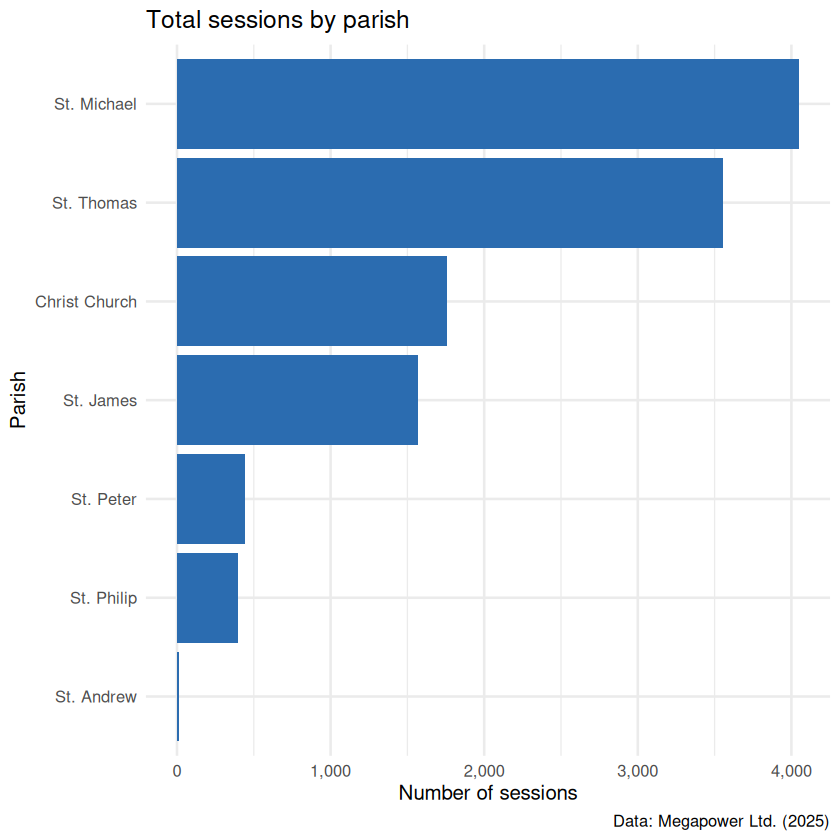

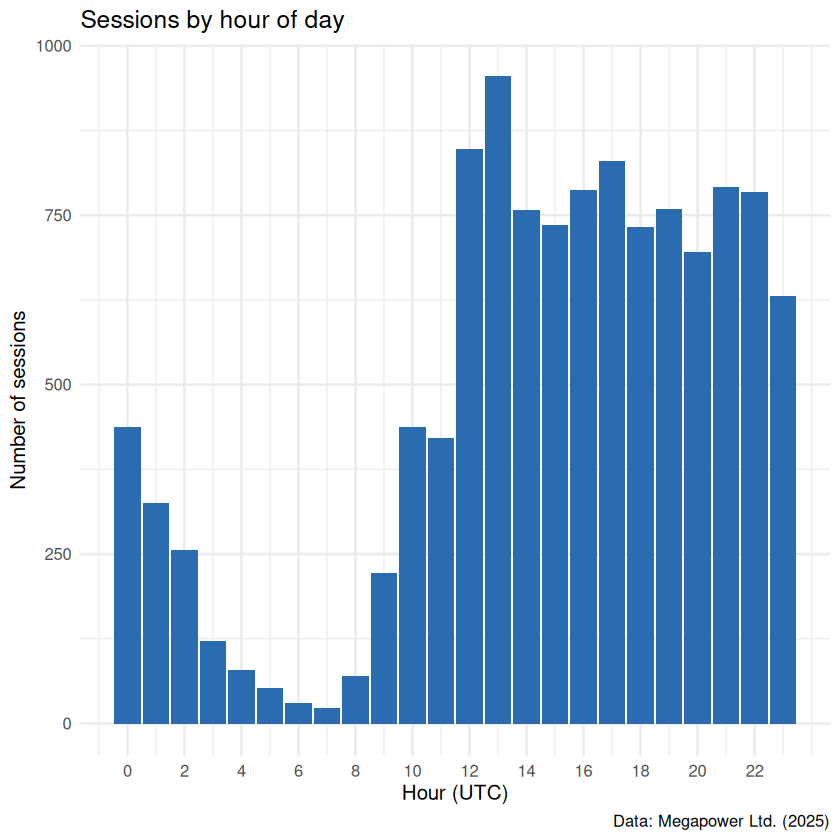

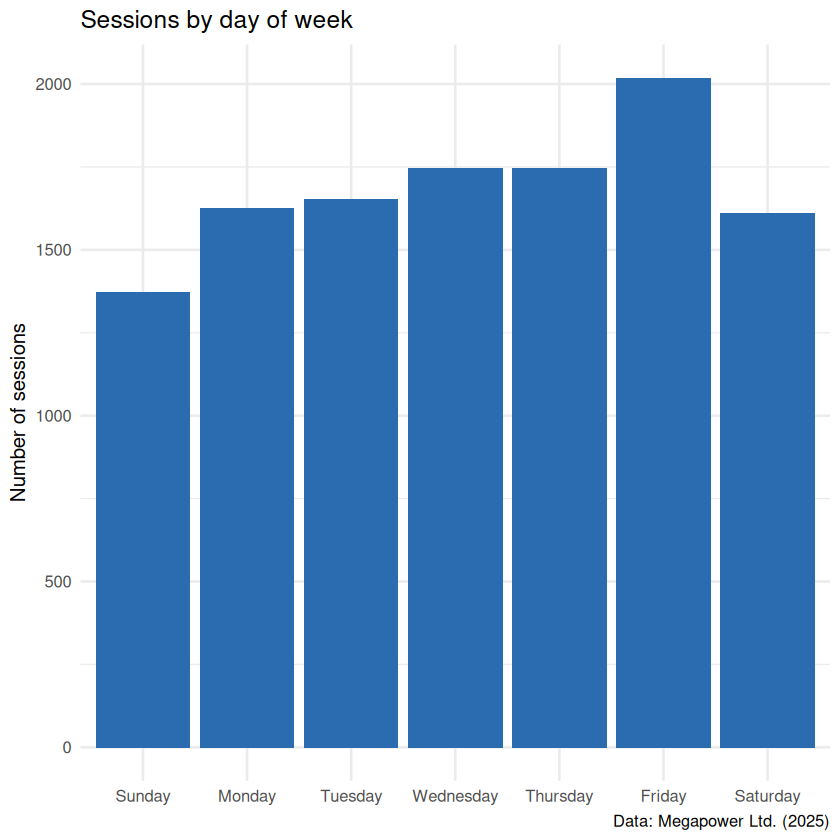

Sessions EDA complete.


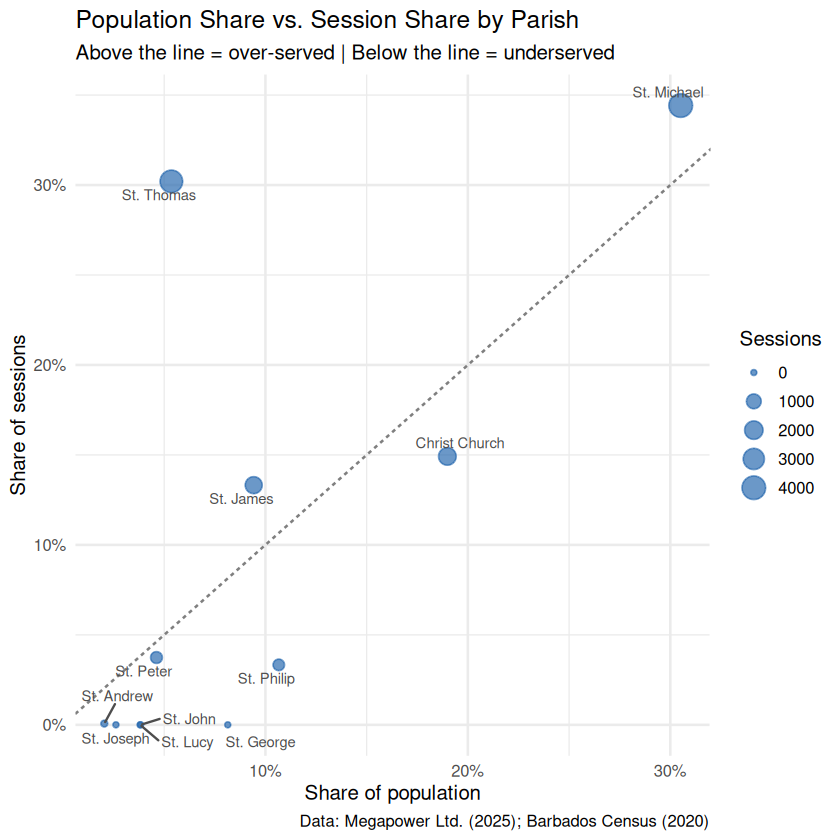

In [102]:
# Exploratory Data Analysis: Sessions
# Summary statistics
# Review the range and distribution of all numeric columns in the sessions file

summary(sessions %>% select(where(is.numeric)))


# Missing values and duplicates
# No missing values are expected. Duplicate rows would indicate data entry errors

sessions %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "column", values_to = "n_missing") %>%
  filter(n_missing > 0)

cat("Duplicate rows in sessions:", sum(duplicated(sessions)), "\n")
cat("Duplicate rows in stats:", sum(duplicated(stats)), "\n")


# Parse datetimes
# Timestamp columns are stored as strings. Parse them and extract
# Hour of day and day of week for temporal analysis

sessions <- sessions %>%
  mutate(
    session_start_utc = mdy_hm(session_start_utc),
    session_end_utc   = mdy_hm(session_end_utc),
    hour_of_day       = hour(session_start_utc),
    day_of_week       = wday(session_start_utc, label = TRUE, abbr = FALSE),
    month             = month(session_start_utc, label = TRUE, abbr = FALSE)
  )

cat("Date range:", format(min(sessions$session_start_utc)), "to",
    format(max(sessions$session_end_utc)), "\n")


# Standardise parish names
# Both files use inconsistent naming (e.g. `"St James"` vs `"St. James"`)
# Standardise to dot notation to match the population file.

sessions <- sessions %>%
  mutate(location_parish = case_when(
    location_parish == "St James"  ~ "St. James",
    location_parish == "St Thomas" ~ "St. Thomas",
    TRUE ~ location_parish
  ))

stats <- stats %>%
  mutate(
    location_parish = str_trim(location_parish),
    location_parish = case_when(
      location_parish == "St James"  ~ "St. James",
      location_parish == "St Thomas" ~ "St. Thomas",
      location_parish == "St Andrew" ~ "St. Andrew",
      TRUE ~ location_parish
    ))

cat("Parishes in sessions:", paste(sort(unique(sessions$location_parish)), collapse = ", "), "\n")


# Data quality flags
# Identify zero-energy sessions, extreme durations, and power outliers

cat("Zero-energy sessions:", sum(sessions$energy_provided_kWh == 0),
    "(", round(mean(sessions$energy_provided_kWh == 0) * 100, 1), "%)\n")
cat("Zero-duration sessions:", sum(sessions$session_duration_min == 0), "\n")
cat("Sessions > 24 hours:", sum(sessions$session_duration_min > 1440), "\n")
cat("Peak power outliers > 200 kW:", sum(sessions$session_peak_power_kW > 200), "\n")
cat("Wrong timezone (non-Barbados):", sum(sessions$local_time_zone != "America/Barbados"), "\n")


# Session duration distribution
# Most sessions are under 4 hours. Extreme values (> 24 hours) are likely logging errors.

sessions %>%
  filter(session_duration_min > 0, session_duration_min <= 1440) %>%
  ggplot(aes(x = session_duration_min)) +
  geom_histogram(bins = 60, fill = "#2B6CB0", colour = "white", linewidth = 0.2) +
  scale_x_continuous(labels = label_number(suffix = " min")) +
  labs(title = "Session duration distribution (capped at 24 hours)",
       x = "Session duration (minutes)", y = "Number of sessions",
       caption = "Data: Megapower Ltd. (2025)")


# Energy delivered distribution
# Right-skewed — most sessions deliver under 30 kWh. Zero-energy sessions are excluded here.

sessions %>%
  filter(energy_provided_kWh > 0) %>%
  ggplot(aes(x = energy_provided_kWh)) +
  geom_histogram(bins = 50, fill = "#276749", colour = "white", linewidth = 0.2) +
  labs(title = "Energy delivered per session (zero-energy sessions excluded)",
       x = "Energy provided (kWh)", y = "Number of sessions",
       caption = "Data: Megapower Ltd. (2025)")


# Sessions per charger
# A small number of chargers account for most sessions — utilisation is heavily concentrated

sessions %>%
  count(charger_display_id, sort = TRUE) %>%
  mutate(charger_display_id = fct_reorder(charger_display_id, n)) %>%
  ggplot(aes(x = n, y = charger_display_id)) +
  geom_col(fill = "#2B6CB0") +
  scale_x_continuous(labels = label_comma()) +
  labs(title = "Total sessions per charger",
       x = "Number of sessions", y = "Charger ID",
       caption = "Data: Megapower Ltd. (2025)")

# What share do the top 5 chargers account for?
top5_pct <- sessions %>%
  count(charger_display_id, sort = TRUE) %>%
  slice_head(n = 5) %>%
  summarise(top5_pct = round(sum(n) / nrow(sessions) * 100, 1)) %>%
  pull(top5_pct)

cat("Top 5 chargers:", top5_pct, "% of all sessions\n")

# Sessions by parish
# St. Thomas and St. Michael dominate. Several parishes have little or no charging activity

sessions %>%
  count(location_parish, sort = TRUE) %>%
  mutate(location_parish = fct_reorder(location_parish, n)) %>%
  ggplot(aes(x = n, y = location_parish)) +
  geom_col(fill = "#2B6CB0") +
  scale_x_continuous(labels = label_comma()) +
  labs(title = "Total sessions by parish",
       x = "Number of sessions", y = "Parish",
       caption = "Data: Megapower Ltd. (2025)")


# Time-of-day pattern
# Charging peaks in the morning, consistent with commuter or workplace use

sessions %>%
  count(hour_of_day) %>%
  ggplot(aes(x = hour_of_day, y = n)) +
  geom_col(fill = "#2B6CB0") +
  scale_x_continuous(breaks = seq(0, 23, 2)) +
  labs(title = "Sessions by hour of day",
       x = "Hour (UTC)", y = "Number of sessions",
       caption = "Data: Megapower Ltd. (2025)")


# Day-of-week pattern
# Weekdays see more activity than weekends across most parishes

sessions %>%
  count(day_of_week) %>%
  ggplot(aes(x = day_of_week, y = n)) +
  geom_col(fill = "#2B6CB0") +
  labs(title = "Sessions by day of week",
       x = NULL, y = "Number of sessions",
       caption = "Data: Megapower Ltd. (2025)")

# Preliminary equity check
# Compare each parish's share of charging sessions against its share of the national population
# Parishes above the diagonal receive more charging access than their population would suggest

session_share <- sessions %>%
  count(location_parish) %>%
  mutate(session_share = n / sum(n))

equity_preview <- pop %>%
  mutate(pop_share = population / sum(population)) %>%
  left_join(session_share, by = c("parish" = "location_parish")) %>%
  replace_na(list(n = 0, session_share = 0))

equity_preview %>%
  ggplot(aes(x = pop_share, y = session_share, label = parish)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "grey50") +
  geom_point(aes(size = n), colour = "#2B6CB0", alpha = 0.7) +
  geom_text_repel(size = 3, colour = "grey30") +
  scale_x_continuous(labels = percent_format(accuracy = 1)) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  labs(title = "Population Share vs. Session Share by Parish",
       subtitle = "Above the line = over-served | Below the line = underserved",
       x = "Share of population", y = "Share of sessions",
       size = "Sessions",
       caption = "Data: Megapower Ltd. (2025); Barbados Census (2020)")


# EDA summary: sessions file
# Data quality issues:
# - Datetime columns stored as strings — parsed with `lubridate`
# - 345 sessions with incorrect timezone labels
# - 1,314 zero-energy sessions (11%) — exclude from energy analysis
# - 67 sessions exceeding 24 hours — likely logging errors
# - 61 peak power outliers > 200 kW — exclude from power analysis
# - Parish name inconsistencies — standardised across all (cleaned) files

# Key findings:
# - Top 5 chargers account for ~50% of all sessions
# - Peak demand occurs on weekday mornings
# - St. Thomas is heavily over-served relative to its population
# - 4 parishes with a combined population > 52,000 have zero charger sessions

# These findings directly inform the visualisations and analysis presented in the final methods and analysis section

cat("Sessions EDA complete.\n")

charger_display_id,location_name,location_parish,local_time_zone,geolocation,start_date,end_date,sessions_count,unique_drivers_count,charging_time_min,energy_provided_kWh,latitude,longitude,start_date_parsed,month_label
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<date>,<fct>
MP-025,Massy Warrens,St. Michael,America/Barbados,"13.1418840472076,-59.6087500021415",1/1/2025,1/31/2025,167,42,7886.50,3618.0,13.14188,-59.60875,2025-01-01,Jan
MP-001,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",1/1/2025,1/31/2025,5,3,89.19,11.0,13.18502,-59.63743,2025-01-01,Jan
MP-0079,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",1/1/2025,1/31/2025,15,11,300.82,110.3,13.18502,-59.63743,2025-01-01,Jan
MP-001,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",2/1/2025,2/28/2025,7,3,505.95,62.4,13.18502,-59.63743,2025-02-01,Feb
MP-025,Massy Warrens,St. Michael,America/Barbados,"13.1418840472076,-59.6087500021415",2/1/2025,2/28/2025,133,39,6038.50,2728.2,13.14188,-59.60875,2025-02-01,Feb
MP-0079,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",2/1/2025,2/28/2025,8,6,140.73,51.6,13.18502,-59.63743,2025-02-01,Feb
MP-025,Massy Warrens,St. Michael,America/Barbados,"13.1418840472076,-59.6087500021415",3/1/2025,3/31/2025,129,39,6660.46,3131.9,13.14188,-59.60875,2025-03-01,Mar
MP-001,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",3/1/2025,3/31/2025,11,3,587.03,72.4,13.18502,-59.63743,2025-03-01,Mar
MP-0079,Massy Sunset Crest,St. James,America/Barbados,"13.1850239447129,-59.6374305021412",3/1/2025,3/31/2025,20,8,292.04,107.1,13.18502,-59.63743,2025-03-01,Mar


 sessions_count   unique_drivers_count charging_time_min energy_provided_kWh
 Min.   :  0.00   Min.   : 0.000       Min.   :    0.0   Min.   :   0.0     
 1st Qu.:  4.00   1st Qu.: 2.000       1st Qu.:  137.7   1st Qu.:  41.1     
 Median : 13.50   Median : 5.000       Median :  954.8   Median : 199.0     
 Mean   : 25.12   Mean   : 8.234       Mean   : 1916.2   Mean   : 422.3     
 3rd Qu.: 29.00   3rd Qu.: 9.000       3rd Qu.: 2729.4   3rd Qu.: 414.7     
 Max.   :195.00   Max.   :54.000       Max.   :13009.9   Max.   :5660.4     
    latitude       longitude     
 Min.   :13.05   Min.   :-59.64  
 1st Qu.:13.08   1st Qu.:-59.61  
 Median :13.13   Median :-59.61  
 Mean   :13.13   Mean   :-59.59  
 3rd Qu.:13.16   3rd Qu.:-59.58  
 Max.   :13.26   Max.   :-59.45  

column,n_missing
<chr>,<int>


Duplicate rows: 0 


start_date,end_date
<chr>,<chr>
1/1/2025,1/31/2025
10/1/2025,10/31/2025
11/1/2025,11/30/2025
12/1/2025,12/31/2025
2/1/2025,2/28/2025
3/1/2025,3/31/2025
4/1/2025,4/30/2025
5/1/2025,5/31/2025
6/1/2025,6/30/2025


...

In stats but not sessions: MP-022, MP-70, MP-020, MP-Sunlink, MP-100, MP-110 


In sessions but not stats:  


Latitude range: 13.0536 to 13.2641 


Longitude range: -59.6443 to -59.4452 


Parsing failures: 0 


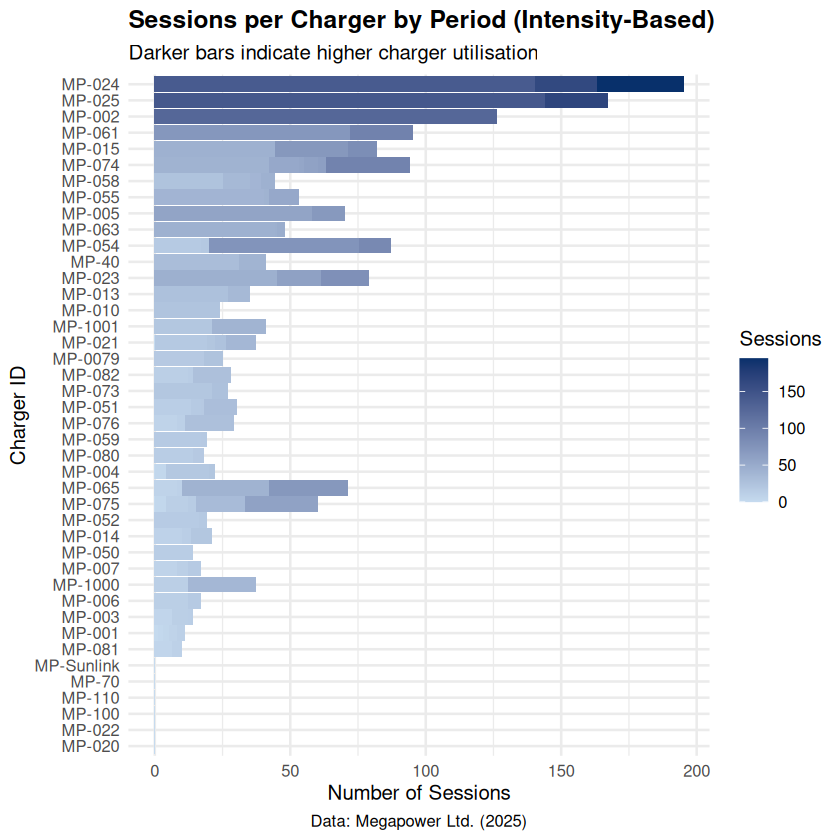

# A tibble: 12 × 6
   month_label start_date_parsed total_sessions total_energy total_drivers
   <fct>       <date>                     <dbl>        <dbl>         <dbl>
 1 Jan         2025-01-01                  1032       15328.           288
 2 Feb         2025-02-01                   935       15206.           293
 3 Mar         2025-03-01                   985       16758.           324
 4 Apr         2025-04-01                   871       14691.           274
 5 May         2025-05-01                   928       15574.           304
 6 Jun         2025-06-01                   934       16887.           318
 7 Jul         2025-07-01                  1013       17459            308
 8 Aug         2025-08-01                   960       16574.           332
 9 Sep         2025-09-01                   987       17266.           337
10 Oct         2025-10-01                  1077       17780.           360
11 Nov         2025-11-01                   988       15467.           351
12 Dec

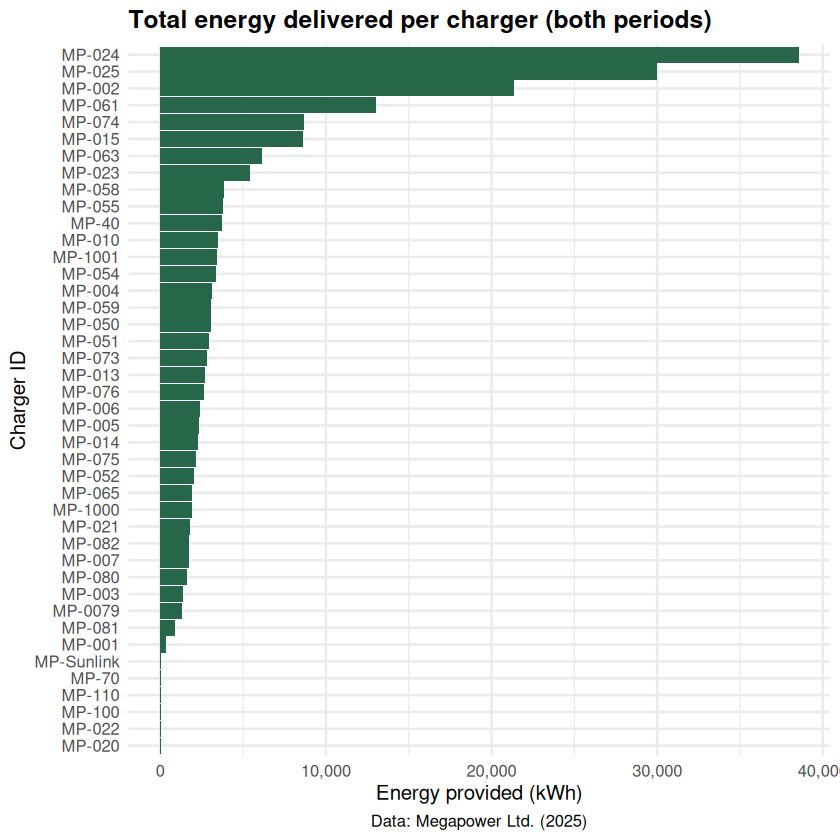

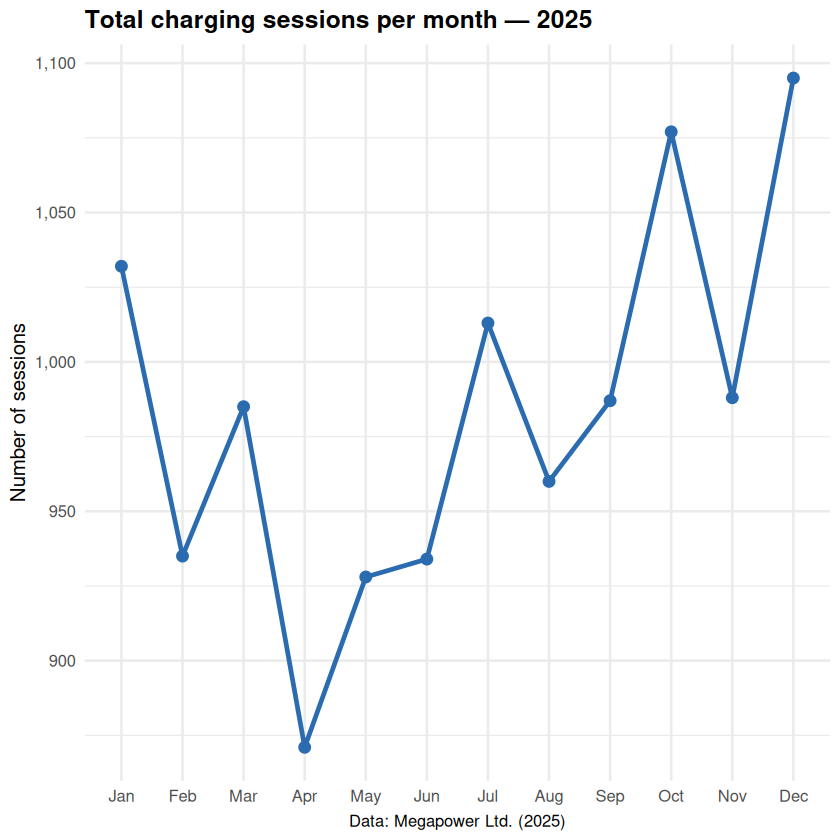

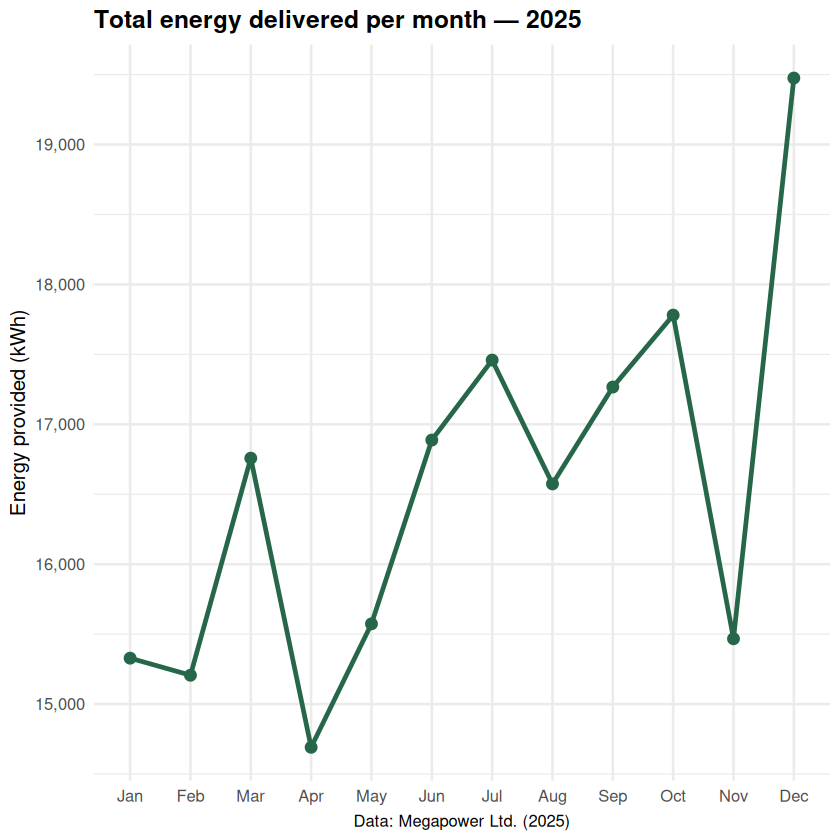

Highest session month: Dec — 1095 sessions


Lowest session month: Apr — 871 sessions


Statistics EDA complete.


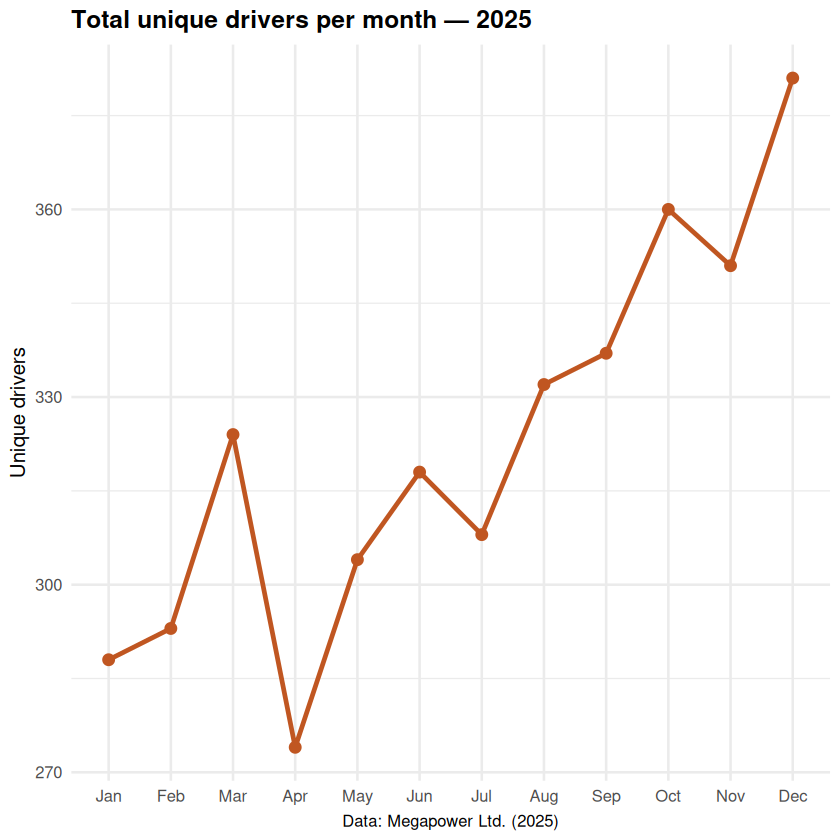

In [77]:
# Exploratory Data Analysis: Statistics File
# Initial exploration of the monthly charger statistics dataset

# Preview data
head(stats, 10)


# Summary statistics
# Review the range and distribution of all numeric columns.
summary(stats %>% select(where(is.numeric)))

# Missing values and duplicates
# Check for any `NA` values and duplicate rows

stats %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "column", values_to = "n_missing") %>%
  filter(n_missing > 0)

cat("Duplicate rows:", sum(duplicated(stats)), "\n")


# Summary periods
# Identify which monthly periods are covered. Only two months are present —
# January and December 2025. Full-year monthly data is not available.

stats %>%
  distinct(start_date, end_date) %>%
  arrange(start_date)

stats %>%
  count(start_date) %>%
  rename(period_start = start_date, n_chargers = n)

# Parish name consistency
# Check for naming inconsistencies before standardising to dot notation.

stats %>% count(location_parish, sort = TRUE)

# Standardise
stats <- stats %>%
  mutate(
    location_parish = str_trim(location_parish),
    location_parish = case_when(
      location_parish == "St James"  ~ "St. James",
      location_parish == "St Thomas" ~ "St. Thomas",
      location_parish == "St Andrew" ~ "St. Andrew",
      TRUE ~ location_parish
    ))

cat("Parishes after fix:", paste(sort(unique(stats$location_parish)), collapse = ", "), "\n")


# Charger ID cross-check
# Four charger IDs appear in the statistics file but have no session records.
# These may represent chargers that were offline or not yet active.

sessions <- read_csv("data/Barbados_public_EV_charger_sessions_full_2025_cleaned.csv")

ids_sessions <- unique(sessions$charger_display_id)
ids_stats    <- unique(stats$charger_display_id)

cat("In stats but not sessions:",
    paste(setdiff(ids_stats, ids_sessions), collapse = ", "), "\n")
cat("In sessions but not stats:",
    paste(setdiff(ids_sessions, ids_stats), collapse = ", "), "\n")

# Parse geolocation
# The `geolocation` column stores coordinates as a single `"lat,lon"'string
# Split into separate columns for spatial analysis

stats <- stats %>%
  mutate(
    latitude  = as.numeric(sub(",.*", "", geolocation)),
    longitude = as.numeric(sub(".*,", "", geolocation))
  )

cat("Latitude range:", round(min(stats$latitude), 4),
    "to", round(max(stats$latitude), 4), "\n")
cat("Longitude range:", round(min(stats$longitude), 4),
    "to", round(max(stats$longitude), 4), "\n")
cat("Parsing failures:", sum(is.na(stats$latitude)), "\n")

# Sessions per charger per period
# Compare session counts across chargers within each summary period
# Confirms the utilisation concentration seen in the sessions file

stats %>%
  mutate(
    charger_display_id = fct_reorder(charger_display_id, sessions_count, sum),
    start_date_parsed = mdy(start_date)
  ) %>%
  ggplot(aes(
    x = sessions_count,
    y = charger_display_id,
    fill = sessions_count   
  )) +
  geom_col(position = "dodge") +
  
  # Gradient scale (light → dark blue)
  scale_fill_gradient(
    low = "#C6DBEF",
    high = "#08306B",
    labels = label_comma()
  ) +
  
  scale_x_continuous(labels = label_comma()) +
  
  labs(
    title = "Sessions per Charger by Period (Intensity-Based)",
    subtitle = "Darker bars indicate higher charger utilisation",
    x = "Number of Sessions",
    y = "Charger ID",
    fill = "Sessions",
    caption = "Data: Megapower Ltd. (2025)"
  ) +
  
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0.5)
)

# Energy delivered per charger
# Total energy aggregated across both summary periods.

stats %>%
  group_by(charger_display_id) %>%
  summarise(total_energy = sum(energy_provided_kWh, na.rm = TRUE)) %>%
  mutate(charger_display_id = fct_reorder(charger_display_id, total_energy)) %>%
  ggplot(aes(x = total_energy, y = charger_display_id)) +
  geom_col(fill = "#276749") +
  scale_x_continuous(labels = label_comma()) +
  labs(title = "Total energy delivered per charger (both periods)",
       x = "Energy provided (kWh)", y = "Charger ID",
       caption = "Data: Megapower Ltd. (2025)") +
  theme(
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0.5)
)

# Monthly trend for 2025

# Parse start_date to a proper date for correct chronological ordering
stats <- stats %>%
  mutate(start_date_parsed = mdy(start_date),
         month_label = format(start_date_parsed, "%b"))

# Order months chronologically
month_order <- stats %>%
  distinct(start_date_parsed, month_label) %>%
  arrange(start_date_parsed) %>%
  pull(month_label)

stats <- stats %>%
  mutate(month_label = factor(month_label, levels = month_order))

# Aggregate across all chargers per month
monthly_summary <- stats %>%
  group_by(month_label, start_date_parsed) %>%
  summarise(
    total_sessions      = sum(sessions_count, na.rm = TRUE),
    total_energy        = sum(energy_provided_kWh, na.rm = TRUE),
    total_drivers       = sum(unique_drivers_count, na.rm = TRUE),
    active_chargers     = n_distinct(charger_display_id[sessions_count > 0]),
    .groups = "drop"
  ) %>%
  arrange(start_date_parsed)

print(monthly_summary)

# Sessions per month
monthly_summary %>%
  ggplot(aes(x = month_label, y = total_sessions, group = 1)) +
  geom_line(colour = "#2B6CB0", linewidth = 1) +
  geom_point(colour = "#2B6CB0", size = 2.5) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Total charging sessions per month — 2025",
       x = NULL, y = "Number of sessions",
       caption = "Data: Megapower Ltd. (2025)") +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0.5)
)
# Energy per month
monthly_summary %>%
  ggplot(aes(x = month_label, y = total_energy, group = 1)) +
  geom_line(colour = "#276749", linewidth = 1) +
  geom_point(colour = "#276749", size = 2.5) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Total energy delivered per month — 2025",
       x = NULL, y = "Energy provided (kWh)",
       caption = "Data: Megapower Ltd. (2025)") +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0.5)
)

# Unique drivers per month
monthly_summary %>%
  ggplot(aes(x = month_label, y = total_drivers, group = 1)) +
  geom_line(colour = "#C05621", linewidth = 1) +
  geom_point(colour = "#C05621", size = 2.5) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Total unique drivers per month — 2025",
       x = NULL, y = "Unique drivers",
       caption = "Data: Megapower Ltd. (2025)") +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0.5)
)

# Peak and lowest months
cat("Highest session month:",
    as.character(monthly_summary$month_label[which.max(monthly_summary$total_sessions)]),
    "—", max(monthly_summary$total_sessions), "sessions\n")
cat("Lowest session month:",
    as.character(monthly_summary$month_label[which.min(monthly_summary$total_sessions)]),
    "—", min(monthly_summary$total_sessions), "sessions\n")

# EDA Summary:Statistics File
# Data quality issues:
# - Parish name inconsistencies — standardised to dot notation
# - `geolocation` stored as a combined string — split into `latitude`/`longitude`
# - 6 charger IDs present in statistics but absent from sessions: MP-020, MP-022, MP-70, MP-Sunlink, MP-100, MP-110

# Key findings:
# - Utilisation concentration in statistics file mirrors sessions file findings
# - Unique driver counts reveal repeat usage patterns not visible in sessions data
# - Some chargers recorded zero sessions in one or both periods

cat("Statistics EDA complete.\n")

Rows: 11 Columns: 4


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): parish
dbl (3): population, area_sq_km, area_sq_miles



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Population file: 11 rows x 4 cols


Rows: 11
Columns: 4
$ parish        <chr> "St. Lucy", "St. Andrew", "St. Joseph", "St. John", "St.…
$ population    <dbl> 10799, 5783, 7410, 10864, 30210, 23065, 53801, 13088, 15…
$ area_sq_km    <dbl> 35.2, 32.1, 26.6, 34.7, 60.5, 44.8, 60.8, 31.5, 33.8, 37…
$ area_sq_miles <dbl> 13.6, 12.4, 10.3, 13.4, 23.4, 17.3, 23.5, 12.2, 13.1, 14…


...

Duplicate rows: 0 


Total parishes: 11 


Total population: 283,356 


parish,population,pop_share
<chr>,<dbl>,<chr>
St. Michael,86465,30.5%
Christ Church,53801,19.0%
St. Philip,30210,10.7%
St. James,26698,9.4%
St. George,23065,8.1%
St. Thomas,15173,5.4%
St. Peter,13088,4.6%
St. John,10864,3.8%
St. Lucy,10799,3.8%


parish,population,area_sq_km,density
<chr>,<dbl>,<dbl>,<dbl>
St. Michael,86465,37.7,2293.5
Christ Church,53801,60.8,884.9
St. James,26698,34.5,773.9
St. George,23065,44.8,514.8
St. Philip,30210,60.5,499.3
St. Thomas,15173,33.8,448.9
St. Peter,13088,31.5,415.5
St. John,10864,34.7,313.1
St. Lucy,10799,35.2,306.8


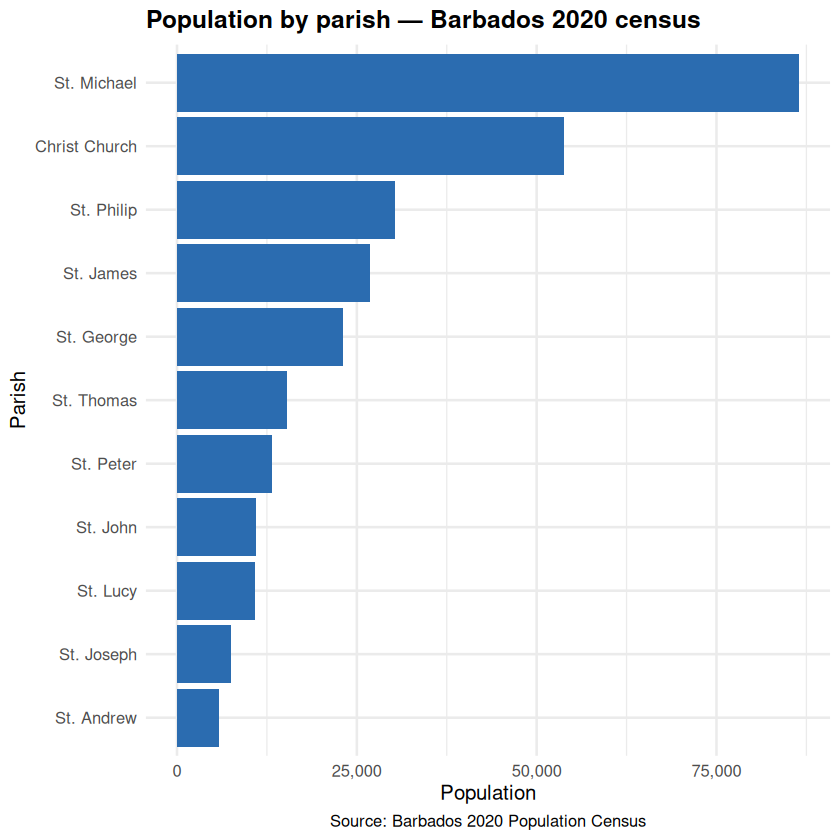

Rows: 11764 Columns: 16


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): session_start_utc, session_end_utc, session_start_local, session_e...
dbl  (6): session_duration_min, idle_duration_min, energy_provided_kWh, sess...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


parish,population,pop_share,has_charger
<chr>,<dbl>,<chr>,<lgl>
St. George,23065,8.1%,FALSE
St. John,10864,3.8%,FALSE
St. Lucy,10799,3.8%,FALSE
St. Joseph,7410,2.6%,FALSE
St. Michael,86465,30.5%,TRUE
Christ Church,53801,19.0%,TRUE
St. Philip,30210,10.7%,TRUE
St. James,26698,9.4%,TRUE
St. Thomas,15173,5.4%,TRUE


Parishes with no public chargers: 4 


Combined population: 52,138 


Share of national population: 18.4 %


Population EDA complete.


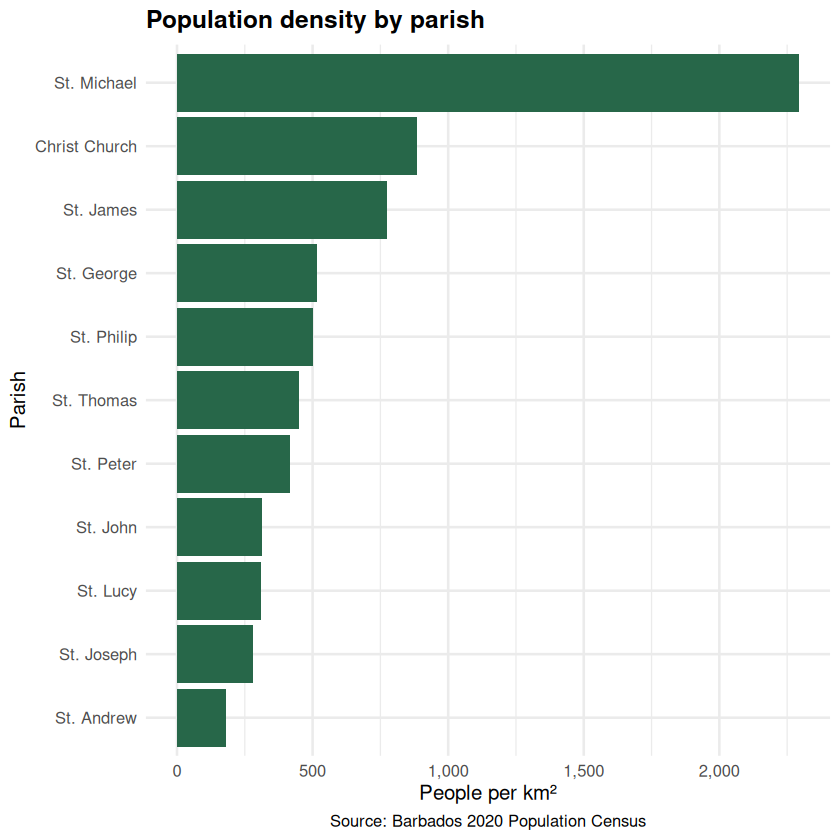

In [78]:
# Exploratory Data Analysis — Population File
# Initial exploration of the Barbados 2020 census population data

# Load data
# Read the population file and confirm dimensions.

pop <- read_csv("data/Barbados_2020_Population_by_Parish.csv")

cat("Population file:", nrow(pop), "rows x", ncol(pop), "cols\n")
glimpse(pop)

# Preview
# All 11 Barbados parishes should be present — one row each
print(pop)

# values and duplicates
# This is a small, clean reference file. No issues are expected.

cat("Missing values:", sum(is.na(pop)), "\n")
cat("Duplicate rows:", sum(duplicated(pop)), "\n")
cat("Total parishes:", nrow(pop), "\n")
cat("Total population:", format(sum(pop$population), big.mark = ","), "\n")

# Population by parish
# St. Michael is by far the most populous parish. St. Andrew is the smallest.
# Parishes with large populations but no chargers represent the biggest access gaps.

pop %>%
  mutate(parish = fct_reorder(parish, population)) %>%
  ggplot(aes(x = population, y = parish)) +
  geom_col(fill = "#2B6CB0") +
  scale_x_continuous(labels = label_comma()) +
  labs(title = "Population by parish — Barbados 2020 census",
       x = "Population", y = "Parish",
       caption = "Source: Barbados 2020 Population Census") +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0.5)
)

# Population share
# Calculate each parish's share of the national population

pop <- pop %>%
  mutate(pop_share = population / sum(population))

pop %>%
  select(parish, population, pop_share) %>%
  mutate(pop_share = percent(pop_share, accuracy = 0.1)) %>%
  arrange(desc(population))

# Area and population density
# Calculate population density (people per km²). Dense parishes may have
# different charging infrastructure needs than sparse ones.

pop <- pop %>%
  mutate(density = round(population / area_sq_km, 1))

pop %>%
  select(parish, population, area_sq_km, density) %>%
  arrange(desc(density))

# Population density by parish
# St. Michael has by far the highest density despite not being the largest
# parish by area — consistent with it being the urban/capital parish.

pop %>%
  mutate(parish = fct_reorder(parish, density)) %>%
  ggplot(aes(x = density, y = parish)) +
  geom_col(fill = "#276749") +
  scale_x_continuous(labels = label_comma()) +
  labs(title = "Population density by parish",
       x = "People per km²", y = "Parish",
       caption = "Source: Barbados 2020 Population Census") +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(hjust = 0.5)
)

# Parish coverage check
# Compare population file parishes against those in the sessions file
# Parishes present in the population file but absent from sessions represent communities with no public charging access at all.

sessions <- read_csv("data/Barbados_public_EV_charger_sessions_full_2025_cleaned.csv") %>%
  mutate(location_parish = case_when(
    location_parish == "St James"  ~ "St. James",
    location_parish == "St Thomas" ~ "St. Thomas",
    TRUE ~ location_parish
  ))

session_parishes <- unique(sessions$location_parish)

pop %>%
  mutate(has_charger = parish %in% session_parishes) %>%
  select(parish, population, pop_share, has_charger) %>%
  mutate(pop_share = percent(pop_share, accuracy = 0.1)) %>%
  arrange(has_charger, desc(population))

# Population without charging access

no_charger_pop <- pop %>%
  filter(!parish %in% session_parishes) %>%
  summarise(
    n_parishes  = n(),
    total_pop   = sum(population),
    pct_of_island = round(sum(pop_share) * 100, 1)
  )

cat("Parishes with no public chargers:", no_charger_pop$n_parishes, "\n")
cat("Combined population:", format(no_charger_pop$total_pop, big.mark = ","), "\n")
cat("Share of national population:", no_charger_pop$pct_of_island, "%\n")


# EDA Summary:Population File

# Data quality:
# - No missing values, no duplicates
# - All 11 parishes present 
# - Naming uses consistent dot notation — matches sessions file after standardisation

# Key findings:
# - St. Michael holds ~30% of the national population and is also the most densely populated parish
# - 4 parishes have no public charging sessions recorded: St. George, St. John, St. Joseph, and St. Lucy
# - These 4 parishes together represent approximately 18% of the national population — a meaningful access gap
# - Population density varies widely, which may be relevant when assessing where new chargers should be prioritised

cat("Population EDA complete.\n")

## Final Analysis and Visualisations



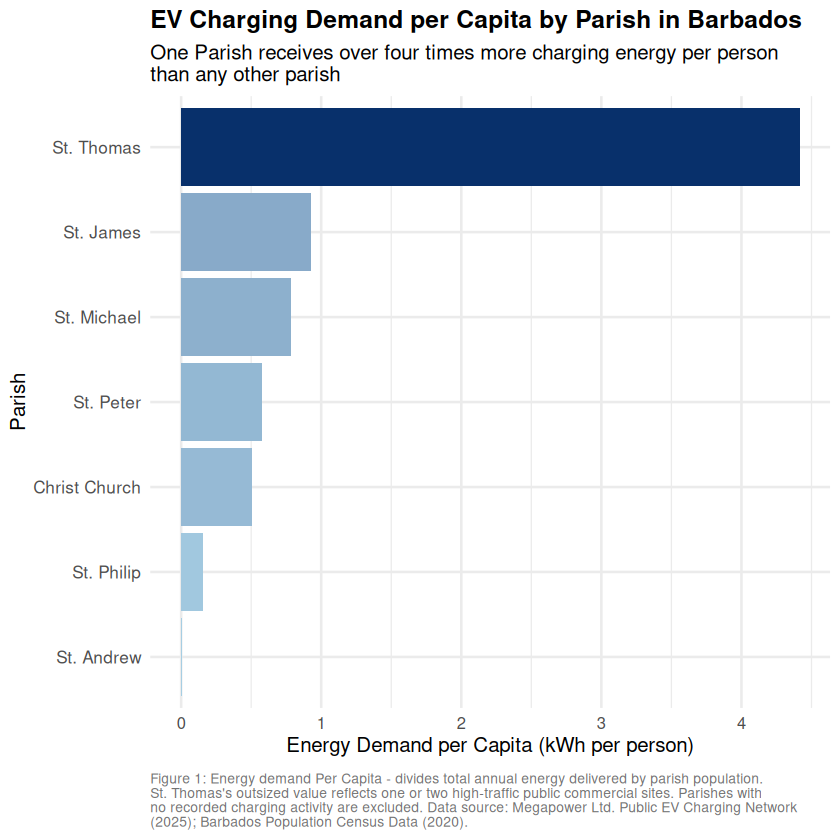

In [79]:
# Create VISUALIZATION 1: Usage Analysis

# Aggregate EV demand by parish

parish_demand <- sessions %>%
  group_by(location_parish) %>%
  summarise(
    total_sessions = n(),
    total_energy_kWh = sum(energy_provided_kWh, na.rm = TRUE),
    .groups = "drop"
  )

# Join with population data
parish_demand_pc <- parish_demand %>%
  left_join(population, by = c("location_parish" = "parish")) %>%
  mutate(
    energy_per_capita = total_energy_kWh / population,
    sessions_per_capita = total_sessions / population
  )

# Create Visualization: Demand per capita

caption_text <- str_wrap(
  " Figure 1: Energy demand Per Capita - divides total annual energy delivered by parish population. St. Thomas's outsized value reflects one or two high-traffic public commercial sites. Parishes with no recorded charging activity are excluded. Data source: Megapower Ltd. Public EV Charging Network (2025); Barbados Population Census Data (2020).",
  width = 100
)
viz1_pc <- ggplot(
  parish_demand_pc,
  aes(
    x = reorder(location_parish, energy_per_capita),
    y = energy_per_capita,
    fill = energy_per_capita
  )
) +

  geom_col() +
  coord_flip() +

  scale_fill_gradient(low = "#A6CEE3", high = "#08306B") +

  labs(
    title = "EV Charging Demand per Capita by Parish in Barbados",
    subtitle = str_wrap(
        "One Parish receives over four times more charging energy per person than any other parish",
        width = 70
    ),
    x = "Parish",
    y = "Energy Demand per Capita (kWh per person)",
    caption = caption_text
  ) +

  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.text.y = element_text(size = 10),
    legend.position = "none",
    plot.caption = element_text(size = 8, colour = "grey45", hjust = 0, margin = margin(t = 10))
  )

# Display plot
viz1_pc

# Save Figure 1 png
ggsave(
  filename = "figure1_per_capita.png",
  plot = viz1_pc,
  width = 8,
  height = 6,
  dpi = 300
)

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


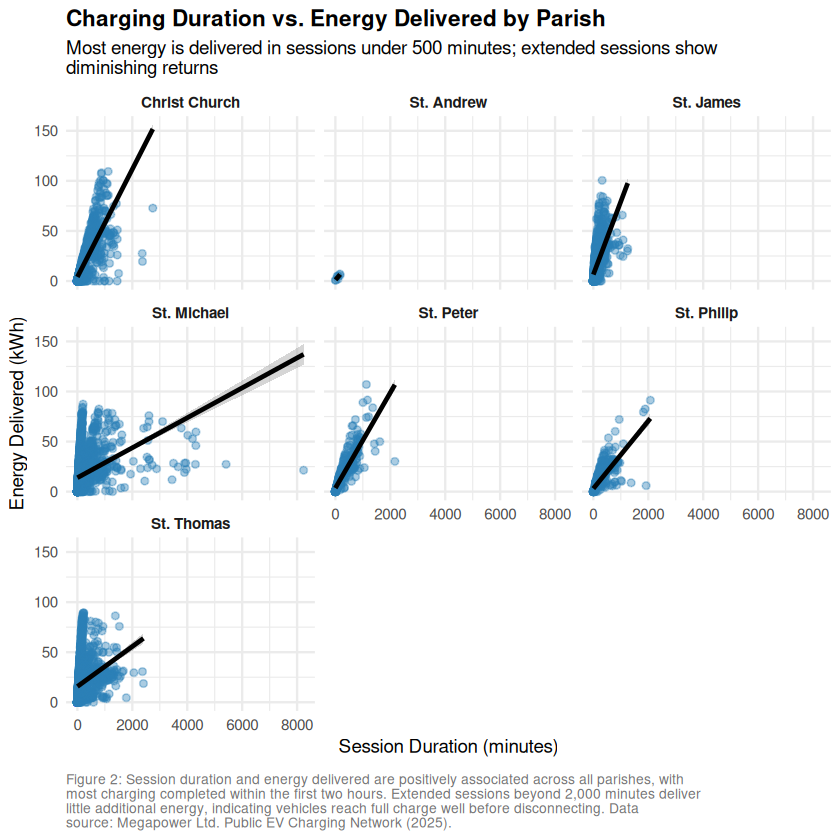

In [80]:
# Create VISUALIZATION 2: Behaviour Analysis

caption_text <- str_wrap(
  " Figure 2: Session duration and energy delivered are positively associated across all parishes, with most charging completed within the first two hours. Extended sessions beyond 2,000 minutes deliver little additional energy, indicating vehicles reach full charge well before disconnecting. Data source: Megapower Ltd. Public EV Charging Network (2025).",
  width = 100
)
viz2 <- ggplot(
  sessions,
  aes(
    x = session_duration_min,
    y = energy_provided_kWh
  )
) +

  # Scatter plot of individual charging sessions
  geom_point(colour = "#2C7FB8", alpha = 0.4) +

  # Linear trend line with confidence interval
  geom_smooth(method = "lm", se = TRUE, color = "black") +

  # Facet by parish to compare geographic variation
  facet_wrap(~ location_parish) +
  
  # Labels and annotations
  labs(
    title = "Charging Duration vs. Energy Delivered by Parish",
    subtitle = str_wrap(
        "Most energy is delivered in sessions under 500 minutes; extended sessions show diminishing returns",
         width =80
    ),
    x = "Session Duration (minutes)",
    y = "Energy Delivered (kWh)",
    caption = caption_text
  ) +

  # Theme settings for cleaner visualization
  theme_minimal(base_size = 11) +
  theme(
    strip.text = element_text(face = "bold"),
    plot.title = element_text(face = "bold"),
    plot.caption = element_text(size = 8, colour = "grey45", hjust = 0, margin = margin(t = 10)),
  )

# Display plot
viz2

# Save Figure 2 png
ggsave(
  filename = "figure2.png",
  plot     = viz2,
  width    = 10,
  height   = 9,
  dpi      = 300
)

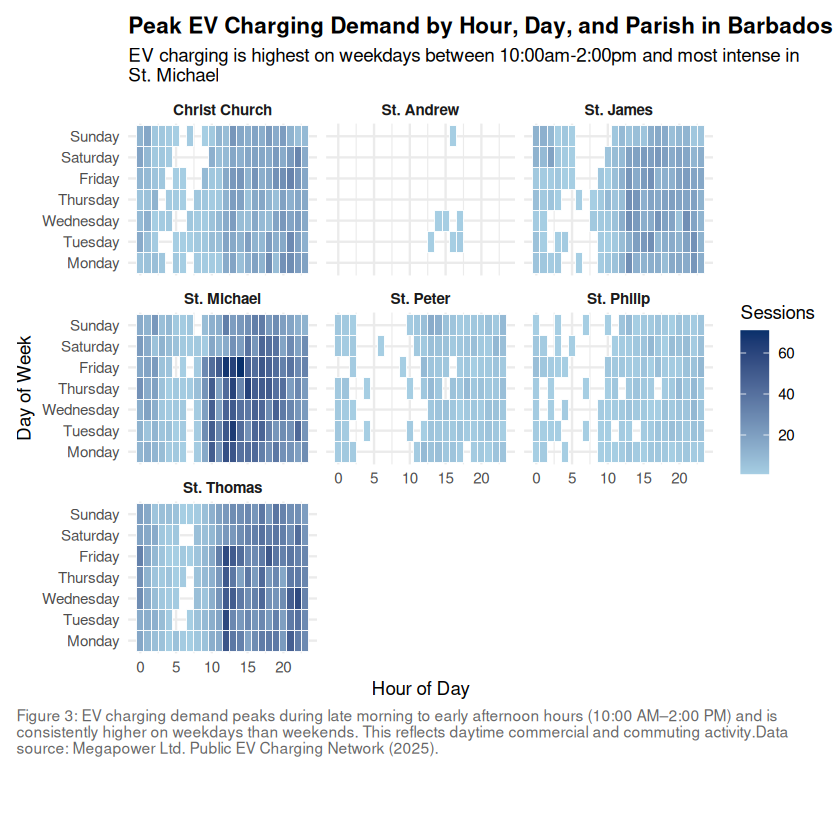

In [81]:
# Create VISUALIZATION 3: Demand Analysis

# Parse datetime and extract hour and day of week
# Convert timestamp strings and extract hour and day of week
sessions <- sessions %>%
  mutate(
    # Convert from given date format (12/31/2024 23:26) into POSIX datetime
    session_start_datetime = mdy_hm(session_start_utc),
    
    # Extract hour of day (0–23)
    hour = hour(session_start_datetime),
    
    # Extract day of week as labeled factor (e.g., Monday, Tuesday, etc.)
    day_of_week = wday(session_start_datetime, label = TRUE, abbr = FALSE)
  )

# Aggregate data
# Group data by parish, day of week, and hour,
# then count number of charging sessions in each combination
heatmap_data <- sessions %>%
  group_by(location_parish, day_of_week, hour) %>%
  summarise(total_sessions = n(), .groups = "drop")

# Ensure proper ordering of weekdays
# Convert day_of_week into an chronological order on the heatmap
heatmap_data$day_of_week <- factor(
  heatmap_data$day_of_week,
  levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday")
)

# Create faceted heatmap visualization
caption_text <- str_wrap(
  "Figure 3: EV charging demand peaks during late morning to early afternoon hours (10:00 AM–2:00 PM) and is consistently higher on weekdays than weekends. This reflects daytime commercial and commuting activity.Data source: Megapower Ltd. Public EV Charging Network (2025).",
  width = 110
)
viz3 <- ggplot(
  heatmap_data, 
  aes(
    x = hour,              
    y = day_of_week,      
    fill = total_sessions  # Color intensity represents number of sessions
  )
) +

  # Create heatmap tiles of aggregated session counts
  geom_tile(color = "white") +

  # Continuous color gradient to show intensity of usage
  scale_fill_gradient(low = "#A6CEE3", high = "#08306B") +

  # Separate plots by parish
  facet_wrap(~ location_parish) +

  # Labels and annotations
  labs(
    title = "Peak EV Charging Demand by Hour, Day, and Parish in Barbados",
    subtitle = str_wrap(
        "EV charging is highest on weekdays between 10:00am-2:00pm and most intense in St. Michael",
         width =80
    ),
    x = "Hour of Day",
    y = "Day of Week",
    fill = "Sessions",
    caption = caption_text
   ) +

  # Theme customization for readability
  theme_minimal(base_size = 11) +
  theme(
    plot.title = element_text(face = "bold"),
    strip.text = element_text(face = "bold"),
    axis.text.x = element_text(angle = 0),
    plot.caption = element_text(hjust = 0, size = 9, colour = "grey40"),
    plot.caption.position = "plot",
    plot.margin = margin(t = 10, r = 10, b = 50, l = 10)
  )

# Display plot
viz3

# Save Figure 3 png
ggsave(
  filename = "figure3.png",
  plot = viz3,
  width = 12,
  height = 12,
  dpi = 300
)


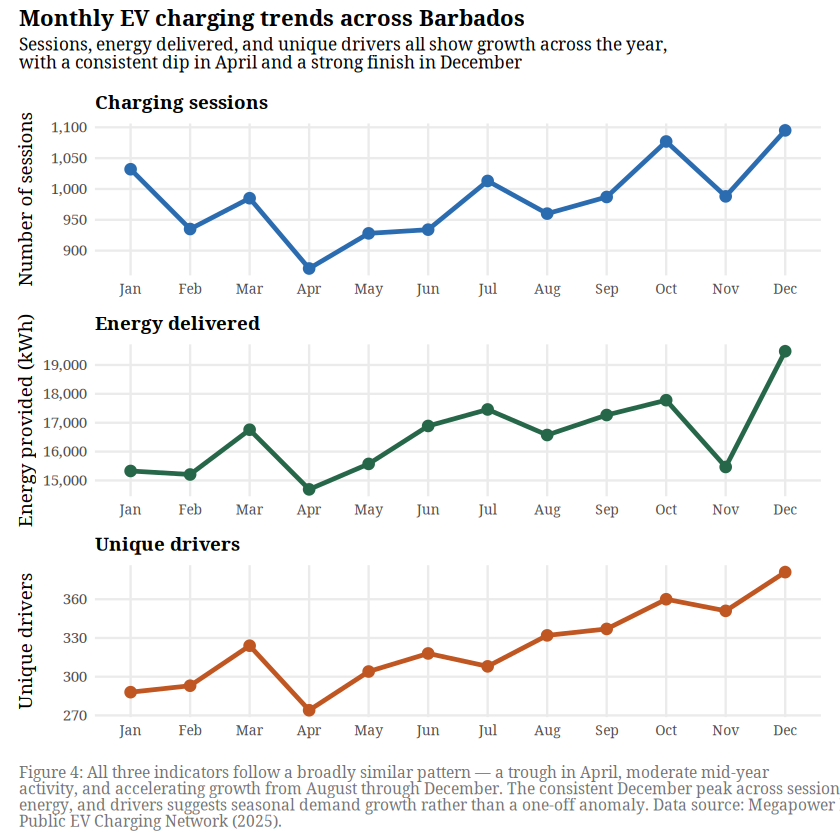

In [96]:
# Create VISUALIZATION 4: Monthly Trend

# Generate separate plots

p1 <- monthly_summary %>%
  ggplot(aes(x = month_label, y = total_sessions, group = 1)) +
  geom_line(colour = "#2B6CB0", linewidth = 1) +
  geom_point(colour = "#2B6CB0", size = 2.5) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Charging sessions",
       x = NULL, y = "Number of sessions") +
  theme_minimal(base_size = 11, base_family = "serif") +
  theme(plot.title = element_text(face = "bold", size = 11),
        axis.text.x = element_text(size = 8),
        panel.grid.minor = element_blank())

p2 <- monthly_summary %>%
  ggplot(aes(x = month_label, y = total_energy, group = 1)) +
  geom_line(colour = "#276749", linewidth = 1) +
  geom_point(colour = "#276749", size = 2.5) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Energy delivered",
       x = NULL, y = "Energy provided (kWh)") +
  theme_minimal(base_size = 11, base_family = "serif") +
  theme(plot.title = element_text(face = "bold", size = 11),
        axis.text.x = element_text(size = 8),
        panel.grid.minor = element_blank())

p3 <- monthly_summary %>%
  ggplot(aes(x = month_label, y = total_drivers, group = 1)) +
  geom_line(colour = "#C05621", linewidth = 1) +
  geom_point(colour = "#C05621", size = 2.5) +
  scale_y_continuous(labels = label_comma()) +
  labs(title = "Unique drivers",
       x = NULL, y = "Unique drivers") +
  theme_minimal(base_size = 11, base_family = "serif") +
  theme(plot.title = element_text(face = "bold", size = 11),
        axis.text.x = element_text(size = 8),
        panel.grid.minor = element_blank())

# Display plots together

viz4 <- (p1 / p2 / p3) +
  plot_annotation(
    title   = "Monthly EV charging trends across Barbados",
    subtitle = "Sessions, energy delivered, and unique drivers all show growth across the year,\nwith a consistent dip in April and a strong finish in December",
    caption  = str_wrap(
      "Figure 4: All three indicators follow a broadly similar pattern — a trough in April, moderate mid-year activity, and accelerating growth from August through December. The consistent December peak across sessions, energy, and drivers suggests seasonal demand growth rather than a one-off anomaly. Data source: Megapower Ltd. Public EV Charging Network (2025).",
      width = 110
    ),
      
# Clean theme
    theme = theme(
          plot.title            = element_text(face = "bold", size = 13,
                                               family = "serif",
                                               margin = margin(b = 4)),
          plot.subtitle         = element_text(size = 10, colour = "black",
                                               family = "serif",
                                               margin = margin(b = 8)),
          plot.caption          = element_text(size = 9, colour = "grey45",
                                               family = "serif",
                                               hjust = 0, margin = margin(t = 10)),
          plot.caption.position = "plot"
        )
      )

# Display plot
viz4

# Save figure 6 png
ggsave(
  filename = "figure4.png",
  plot     = viz4,
  width    = 8,
  height   = 10,
  dpi      = 300
)

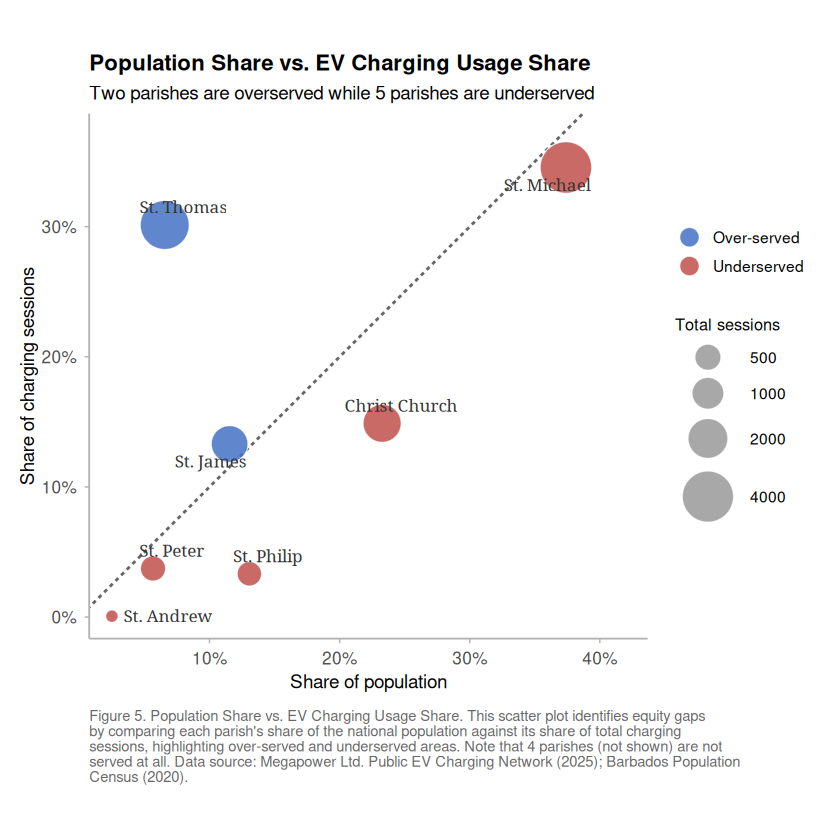

In [99]:
# Create VISUALIZATION 5: Equity Analysis

# Aggregate usage
usage_by_parish <- stats %>%
  group_by(location_parish) %>%
  summarise(
    total_sessions = sum(sessions_count, na.rm = TRUE),
    .groups = "drop"
  )

# Merge with population
equity_data <- usage_by_parish %>%
  left_join(population, by = c("location_parish" = "parish"))

# Remove parishes with missing population data
equity_data <- equity_data %>%
  filter(!is.na(population))

# Calculate shares
equity_data <- equity_data %>%
  mutate(
    population_share = population / sum(population, na.rm = TRUE),
    usage_share      = total_sessions / sum(total_sessions, na.rm = TRUE),
    equity_gap       = usage_share - population_share,
    serve_status     = if_else(equity_gap >= 0, "Over-served", "Underserved")
  )

# Colour palette
fill_colours <- c("Over-served" = "#4472C4", "Underserved" = "#C0504D")

# Caption
caption_text <- str_wrap(
  "Figure 5. Population Share vs. EV Charging Usage Share. This scatter plot identifies equity gaps by comparing each parish's share of the national population against its share of total charging sessions, highlighting over-served and underserved areas. Note that 4 parishes (not shown) are not served at all. Data source: Megapower Ltd. Public EV Charging Network (2025); Barbados Population Census (2020).",
  width = 100
)
  
viz5 <- ggplot(equity_data,
               aes(x = population_share, y = usage_share)) +

  # Reference diagonal
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", linewidth = 0.6, colour = "grey40") +

   # Bubbles
  geom_point(aes(size = total_sessions, fill = serve_status),
             shape = 21, colour = "white", stroke = 0.4, alpha = 0.85) +

  # Non-overlapping parish labels
  geom_text_repel(
    aes(label = location_parish),
    size          = 3.5,
    family        = "serif",
    fontface      = "plain",
    colour        = "grey20",
    box.padding   = 0.4,
    point.padding = 0.3,
    segment.colour = "grey60",
    segment.size   = 0.3,
    max.overlaps   = 20
  ) +

  # Scales
  scale_fill_manual(values = fill_colours, name = NULL) +
  scale_size_continuous(
    name   = "Total sessions",
    range  = c(3, 14),
    breaks = c(500, 1000, 2000, 4000)
  ) +
  scale_x_continuous(
    labels = percent_format(accuracy = 1),
    expand = expansion(mult = c(0.05, 0.18))
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    expand = expansion(mult = c(0.05, 0.12))
  ) +
  coord_fixed(ratio = 1) +

  # Labels
  labs(
    title   = "Population Share vs. EV Charging Usage Share ",
    subtitle = "Two parishes are overserved while 5 parishes are underserved",
    x       = "Share of population",
    y       = "Share of charging sessions",
    caption = caption_text 
  ) +

  # Clean theme
  theme_minimal(base_size = 11) +
  theme(
    plot.title      = element_text(size = 13, face = "bold",
                                   margin = margin(b = 6)),
    plot.caption    = element_text(size = 8.5, colour = "grey40",
                                   hjust = 0, margin = margin(t = 10)),
    axis.title      = element_text(size = 11),
    axis.text       = element_text(size = 10, colour = "grey30"),
    axis.line       = element_line(colour = "grey70", linewidth = 0.4),
    axis.ticks      = element_line(colour = "grey70", linewidth = 0.3),
    panel.grid      = element_blank(),
    legend.position = "right",
    legend.title    = element_text(size = 9.5),
    legend.text     = element_text(size = 9),
    legend.key      = element_blank(),
    plot.margin     = margin(12, 16, 12, 12)
  ) +

  guides(
    fill = guide_legend(override.aes = list(size = 5)),
    size = guide_legend(override.aes = list(fill = "grey60"))
  )

# Display plot
viz5

# Save figure 5 png
ggsave(
  filename = "figure.png",
  plot     = viz5,
  width    = 10,
  height   = 9,
  dpi      = 300
)

Zoom: 11



Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


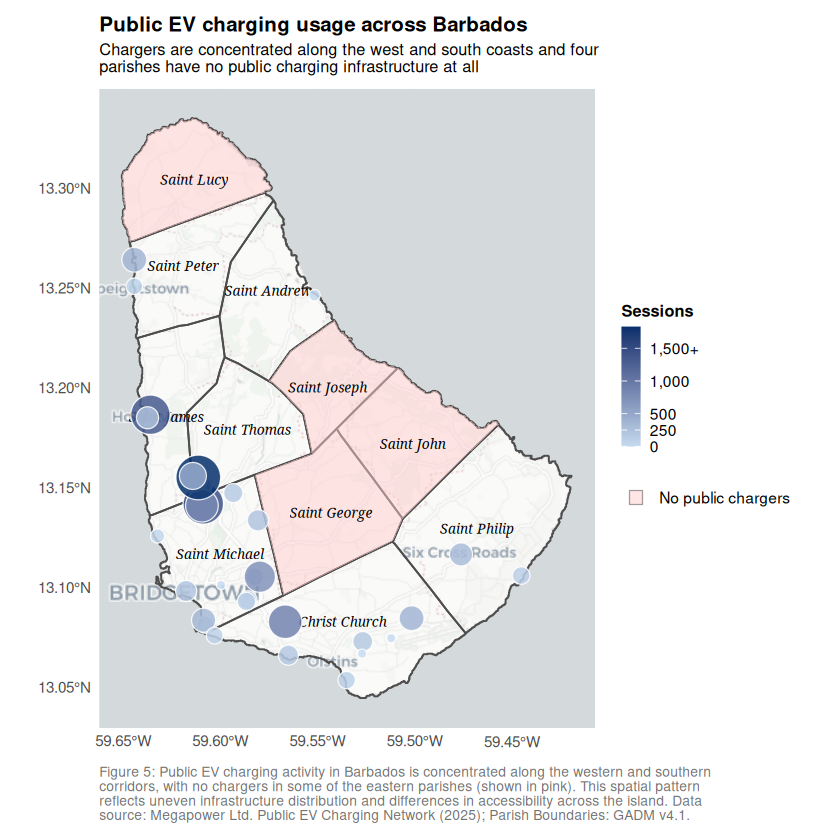

In [104]:
# Create VISUALIZATION 6: Spatial Distribution with Size-Based Intensity

# Split geolocation into lat/lon
stats <- stats %>%
  mutate(
    latitude  = as.numeric(sub(",.*", "", geolocation)),
    longitude = as.numeric(sub(".*,", "", geolocation))
  )

# Aggregate total annual sessions per unique charger location
stats_agg <- stats %>%
  group_by(location_name, latitude, longitude) %>%
  summarise(sessions_count = sum(sessions_count, na.rm = TRUE), .groups = "drop")

# Download Barbados parish boundaries from GADM
barbados_parishes <- gadm("BRB", level = 1, path = tempdir())
barbados_sf       <- st_as_sf(barbados_parishes)

# Convert charger data to spatial object
stats_sf <- st_as_sf(
  stats_agg,
  coords = c("longitude", "latitude"),
  crs    = 4326
)

# Identify parishes with no chargers (using GADM "Saint" spelling)
no_charger_parishes <- barbados_sf %>%
  filter(NAME_1 %in% c("Saint Lucy", "Saint George", "Saint John", "Saint Joseph"))

# Dummy data frame for no-charger legend entry
no_charger_legend <- data.frame(
  x     = NA_real_,
  y     = NA_real_,
  label = "No public chargers"
)

# Caption
caption_text <- str_wrap(
  "Figure 5: Public EV charging activity in Barbados is concentrated along the western and southern corridors, with no chargers in some of the eastern parishes (shown in pink). This spatial pattern reflects uneven infrastructure distribution and differences in accessibility across the island. Data source: Megapower Ltd. Public EV Charging Network (2025); Parish Boundaries: GADM v4.1.",
  width = 100
)

viz6 <- ggplot() +

  # Minimal basemap
  annotation_map_tile(type = "cartolight", zoom = 11, quiet = TRUE) +

  # Parish boundary lines — all parishes, no fill
  geom_sf(
    data      = barbados_sf,
    fill      = NA,
    colour    = "grey30",
    linewidth = 0.4
  ) +

  # Pink overlay for parishes with no chargers
  geom_sf(
    data    = no_charger_parishes,
    fill    = "#FFCCCC",
    alpha   = 0.5,
    colour  = NA
  ) +

  # Invisible point used solely to generate the no-charger legend entry
  geom_point(
    data  = no_charger_legend,
    aes(x = x, y = y, shape = label),
    fill   = "#FFCCCC",
    colour = "grey30",
    size   = 4,
    stroke = 0.4
  ) +
  scale_shape_manual(
    name   = NULL,
    values = c("No public chargers" = 22),
    guide  = guide_legend(
      override.aes = list(
        fill   = "#FFCCCC",
        colour = "grey30",
        size   = 4,
        alpha  = 0.5
      ),
      order = 2
    )
  ) +

  # Parish name labels
  geom_sf_text(
    data     = barbados_sf,
    aes(label = NAME_1),
    size     = 2.8,
    family   = "serif",
    colour   = "black",
    fontface = "italic"
  ) +

  # Charger bubbles — shape 21 allows fill + white stroke
  geom_sf(
    data   = stats_sf,
    aes(size = sessions_count, fill = sessions_count),
    shape  = 21,
    colour = "white",
    stroke = 0.4,
    alpha  = 0.85
  ) +

  # Blue gradient fill for session intensity
  scale_fill_gradient(
    name   = "Sessions",
    low    = "#c6dbef",
    high   = "#08306b",
    breaks = c(0, 250, 500, 1000, 1500),
    labels = c("0", "250", "500", "1,000", "1,500+"),
    guide  = guide_colorbar(
      barwidth       = 0.8,
      barheight      = 5,
      title.position = "top",
      order          = 1
    )
  ) +

  # Size scale — guide suppressed, fill colourbar carries the legend
  scale_size_continuous(
    name   = "Sessions",
    range  = c(2, 12),
    breaks = c(0, 250, 500, 1000, 1500),
    guide  = "none"
  ) +

  # Labels
  labs(
    title    = "Public EV charging usage across Barbados",
    subtitle = str_wrap(
        "Chargers are concentrated along the west and south coasts and four parishes have no public charging infrastructure at all",
         width = 70
    ),
    x = NULL,
    y = NULL,
    caption = caption_text
  ) +

  # Clean publication theme
  theme_minimal(base_size = 11) +
  theme(
    plot.title      = element_text(face = "bold", size = 12,
                                   margin = margin(b = 4)),
    plot.subtitle   = element_text(size = 9.5, colour = "black",
                                   margin = margin(b = 8)),
    plot.caption    = element_text(size = 8, colour = "grey45",
                                   hjust = 0, margin = margin(t = 10)),
    legend.position = "right",
    legend.title    = element_text(size = 9.5, face = "bold"),
    legend.text     = element_text(size = 9),
    plot.margin     = margin(10, 10, 10, 10)
  )

viz6

ggsave(
  filename = "figure6.png",
  plot     = viz5,
  width    = 12,
  height   = 9,
  dpi      = 300
)

## Ethical Considerations

- <u>_Privacy_</u>: The datasets do not contain any personally identifiable information. Driver identifiers \(in the raw data\) appear only as anonymised IDs. No names, addresses, or contact details are present.
- <u>_Governance_</u>: Data was provided directly by Megapower Ltd., operator of Barbados' public EV charging network, via their \(private\) [ChargeLab.co ](http://ChargeLab.co)account. Use is consistent with the purpose for which data was shared.
- <u>_Bias_</u>: The dataset covers only fully public chargers operated by Megapower Ltd. Private residential chargers, semi\-private or company fleet chargers are excluded, which may understate actual EV usage in certain parishes. Thus, analysis results should not be used to infer overall EV adoption rates.
- <u>_Equity_</u>: Population data used for the per\-capita equity indicator is from the 2020 Barbados census. Population changes since then may affect equity ratios, and should be updated when more recent census data is
  available.

## Acknowledging Limitations

The analysis is based on the `mpg` dataset, which may have limitations such as:

- The dataset covers only the public EV charging network operated by Megapower Ltd. Private
  residential and company fleet chargers, which likely represent significant charging volume
  depending on where users live and work, are excluded.
- This analysis is based on a single year \(2025\) of data. As EV adoption and charger deployment in
  Barbados are actively evolving, findings may not be representative of future patterns, especially now that multiple companies sell EVs in Barbados and are they are all installing residential and fleet\-based commercial charging infrastructure.
- Measurement errors in session durations or energy readings \(present as statistical outliers\) could
  affect calculations of peak usage and average energy delivered. These have been flagged but not
  removed to preserve data integrity.
- The population denominators for parish\-level equity analysis are from the 2020 census and may
  not fully reflect current population distributions.
- Chargers that are newly installed during the analysis period will have fewer sessions than established
  chargers, which may understate their long\-run utilisation potential.

## Results for Non-Technical Audience

Barbados' public EV charging network is being used unevenly: 5 four chargers handle the majority (~ 47.3%) of all charging sessions, while many others sit largely idle. This matters because if these high\-demand chargers become full, EV drivers may not be able to charge reliably, which could discourage people from buying electric vehicles in the first place. At the same time, several parishes have little or no public charging coverage, meaning residents there have fewer options to go electric. The data points to a clear and urgent need: upgrade capacity at the busiest sites and expand the network into underserved parishes to support Barbados' clean transport goals.

**Finding 1**: 5 chargers handle the majority of sessions |
**Recommendation 1**: Add connectors or upgrade to faster chargers at MP\-024, MP\-025, MP\-002, MP\-061, and MP\-015 to reduce queuing risk

**Finding 2**: Many chargers have fewer than 100 annual sessions |
**Recommendation 2**: Assess location suitability; consider relocation or improved signage/promotion

**Finding 3**: Peak demand is weekday\-driven \(especially on Fridays\) and midday\-peaking, indicating strong alignment with commuting and commercial activity |
**Recommendation 3**: Explore demand\-based pricing to spread the load; schedule maintenance at off\-peak hours. Midday peaks align with solar photovoltaic (pv) integration

**Finding 4**: St. Thomas receives over 4× more charging energy per capita than any other parish; ome parishes lack adequate public charging access |
**Recommendation 4**: Set minimum targets for charger availability in each parish (e.g., chargers per population\) and prioritize installing new chargers in parishes that fall below these targets

**Finding 5**: 4 parishes (St. Lucy, St. Joseph, St. George, and St. John) have no public charging access |
**Recommendation 5**:Prioritise strategic deployment of public EV infrastructure in these parishes to close the equity gap

**Finding 6**: Unique driver counts grew from ~288 (Jan) to ~381 (Dec); a 32% increase across the year |
**Recommendation 5**: Monitor growth trajectory; plan network expansion ahead of demand to avoid capacity constraints

**Finding 7**: All three monthly indicators (sessions, energy, drivers) dip in April and peak in December, suggesting seasonal patterns |
**Recommendation 7**: Investigate April dip causes (such as maintenance or seasonal travel); plan adequate capacity for December peaks (likely due to increased commercial activity around the Christmas seasons well as a surge in tourists arrival)

## Instructions for Reproducing Project

1. Clone the GitHub repository \([https://github.com/rasheenadow/Barbados\-Public\-EV\-Charger\-Analysis](https://github.com/rasheenadow/Barbados-Public-EV-Charger-Analysis) \)
2. Install relevant libraries
3. Place the CSV data files in the same directory as the notebook
4. Open and run the provided Jupyter notebook \(Barbados\_EV\_Charger\_Analysis.ipynb\)

